# 분석 4 — 헬스장 고객 이탈 분석

`data/gym_churn_us.csv` (4,000명) 기반.

**분석 범위** — 이탈을 세 각도에서 다루고 마지막에 실행안으로 연결한다.

| 트랙 | 질문 | 방법 |
|---|---|---|
| **A** | 누가 이탈하는가 | 분류 (Churn 예측) |
| **B** | 신규 가입자가 **언제** 이탈하는가 | 회귀 / 생존분석 (Lifetime) |
| **C** | 고객은 어떤 집단으로 나뉘는가 | 군집화 → 이탈군 / 위험군 / 유지군 |
| **D** | 그래서 무엇을 해야 하는가 | 집단별 리텐션 솔루션 도출 |

본 노트북은 **기초 EDA**와 **피처 선택 검증**을 다루며, 트랙별 상세 설계는 마지막 [10. 분석 계획](#10-분석-계획) 참고.

## 0. 환경 설정

노트북은 `__main__`으로 실행되어 상대 import(`from ..src...`)가 불가능하므로,
프로젝트 루트를 `sys.path`에 추가하고 작업 디렉터리도 루트로 옮긴다.
(`load_data()`가 `data/...` 상대경로를 쓰기 때문에 cwd 이동이 필요하다.)

In [30]:
import os
import sys
from pathlib import Path

# src 폴더가 있는 프로젝트 루트를 찾아 올라감
ROOT = Path.cwd()
while not (ROOT / "src").is_dir():
    ROOT = ROOT.parent

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)

ROOT: c:\Users\playdata2\Documents\SKN34-2nd-1Team


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.common.common import SEED, load_data

# 한글 폰트 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 300
sns.set_theme(style="whitegrid", font="Malgun Gothic", rc={"axes.unicode_minus": False})

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("SEED:", SEED)

SEED: 42


## 1. 데이터 불러오기 및 기본 구조

In [32]:
df = load_data()

print("shape:", df.shape)
df.head()

shape: (4000, 14)


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [33]:
# 컬럼별 자료형 / 결측 / 고유값 수
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "결측수": df.isna().sum(),
    "고유값수": df.nunique(),
    "예시값": [df[c].unique()[:4] for c in df.columns],
})

print("중복행:", df.duplicated().sum())
overview

중복행: 0


,dtype,결측수,고유값수,예시값
gender,int64,0,2,"[1, 0]"
Near_Location,int64,0,2,"[1, 0]"
Partner,int64,0,2,"[1, 0]"
Promo_friends,int64,0,2,"[1, 0]"
Phone,int64,0,2,"[0, 1]"
Contract_period,int64,0,3,"[6, 12, 1]"
Group_visits,int64,0,2,"[1, 0]"
Age,int64,0,23,"[29, 31, 28, 33]"
Avg_additional_charges_total,float64,0,4000,"[14.227470422861144, 113.2029376510582, 129.44..."
Month_to_end_contract,float64,0,12,"[5.0, 12.0, 1.0, 6.0]"


### 컬럼 정의

원본(Yandex.Practicum "Model Fitness") 데이터 사전 기준.

| 컬럼 | 의미 |
|---|---|
| `gender` | 성별 (0/1, 어느 쪽이 남/여인지는 원본에 명시 없음) |
| `Near_Location` | 헬스장 인근에 거주 또는 근무하는지 |
| `Partner` | 제휴사 직원인지 (제휴 할인 대상) |
| `Promo_friends` | 친구 추천 프로모션으로 가입했는지 |
| `Phone` | 전화번호 제공 여부 |
| `Contract_period` | 계약 기간(개월) — 실제 데이터는 1 / 6 / 12 |
| `Group_visits` | 그룹 수업 참여 여부 |
| `Age` | 나이 |
| `Avg_additional_charges_total` | 부가 서비스 총 지출액 (카페·용품·마사지 등) |
| `Month_to_end_contract` | 계약 만료까지 남은 개월 수 |
| `Lifetime` | 첫 방문 이후 경과 개월 수 |
| `Avg_class_frequency_total` | 전체 기간 **주당** 평균 방문 횟수 |
| `Avg_class_frequency_current_month` | 직전 한 달 **주당** 평균 방문 횟수 |
| `Churn` | 해당 월 이탈 여부 (타깃) |

방문 빈도 두 컬럼은 "월 방문 횟수"가 아니라 **주당** 평균이다.

In [34]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510,0.500,0.000,0.000,1.000,1.000,1.000
Near_Location,4000.0,0.845,0.362,0.000,1.000,1.000,1.000,1.000
Partner,4000.0,0.487,0.500,0.000,0.000,0.000,1.000,1.000
Promo_friends,4000.0,0.308,0.462,0.000,0.000,0.000,1.000,1.000
Phone,4000.0,0.904,0.295,0.000,1.000,1.000,1.000,1.000
Contract_period,4000.0,4.681,4.550,1.000,1.000,1.000,6.000,12.000
Group_visits,4000.0,0.412,0.492,0.000,0.000,0.000,1.000,1.000
Age,4000.0,29.184,3.258,18.000,27.000,29.000,31.000,41.000
Avg_additional_charges_total,4000.0,146.944,96.356,0.148,68.869,136.220,210.950,552.591
Month_to_end_contract,4000.0,4.323,4.191,1.000,1.000,1.000,6.000,12.000


## 2. 타깃 분포 (Churn)

,인원,비율(%)
유지(0),2939,73.47
이탈(1),1061,26.52


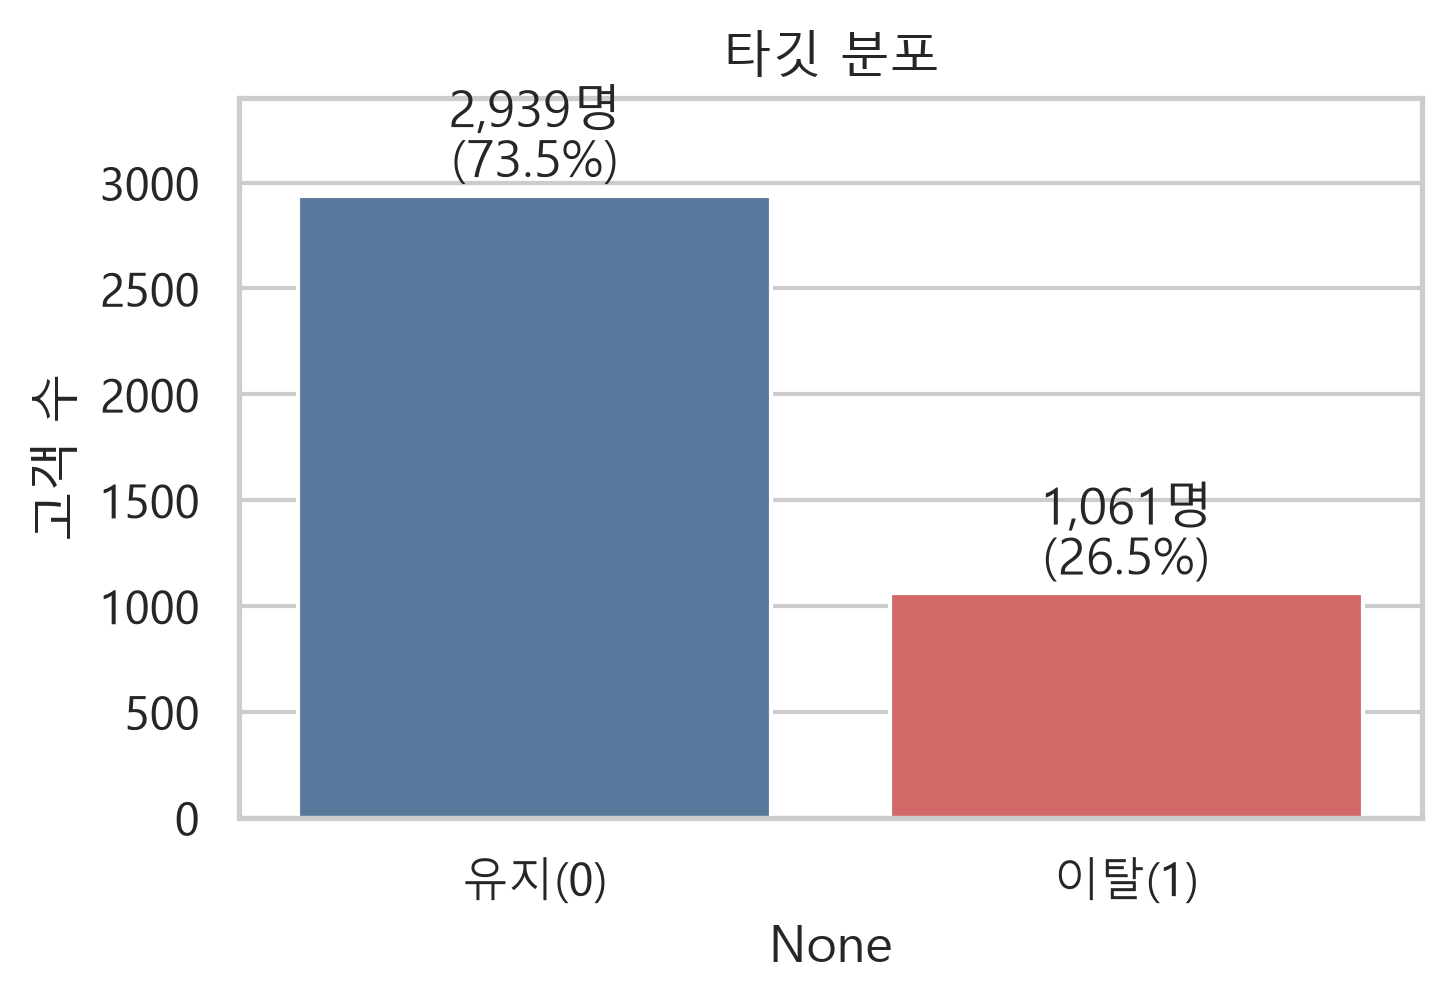

In [35]:
churn_count = df["Churn"].value_counts().sort_index()
churn_ratio = df["Churn"].value_counts(normalize=True).sort_index() * 100

target = pd.DataFrame({
    "인원": churn_count,
    "비율(%)": churn_ratio.round(2),
})
target.index = ["유지(0)", "이탈(1)"]

display(target)

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.barplot(x=target.index, y=target["인원"], hue=target.index,
            palette=["#4C78A8", "#E45756"], legend=False, ax=ax)
for i, v in enumerate(target["인원"]):
    ax.text(i, v + 40, f"{v:,}명\n({target['비율(%)'].iloc[i]:.1f}%)",
            ha="center", va="bottom")
ax.set_title("타깃 분포")
ax.set_ylabel("고객 수")
ax.set_ylim(0, 3400)
plt.tight_layout()
plt.show()

이탈률 **26.5%** — 약 2.8 : 1 불균형.

심한 편은 아니지만 정확도(accuracy)만 보면 "전부 유지로 예측"해도 73.5%가 나오므로,
평가지표는 **ROC-AUC / Recall / F1** 중심으로 봐야 한다.

## 3. 변수 유형 구분

In [36]:
TARGET = "Churn"

BINARY = ["gender", "Near_Location", "Partner", "Promo_friends", "Phone", "Group_visits"]
CATEGORICAL = ["Contract_period"]
NUMERIC = [
    "Age",
    "Avg_additional_charges_total",
    "Month_to_end_contract",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
]

print(f"이진형  {len(BINARY)}개: {BINARY}")
print(f"범주형  {len(CATEGORICAL)}개: {CATEGORICAL} -> {sorted(df['Contract_period'].unique())}")
print(f"수치형  {len(NUMERIC)}개: {NUMERIC}")

이진형  6개: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Group_visits']
범주형  1개: ['Contract_period'] -> [np.int64(1), np.int64(6), np.int64(12)]
수치형  6개: ['Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']


## 4. 수치형 변수 분포

이탈/유지 그룹을 겹쳐 그려 분포 차이를 확인한다.

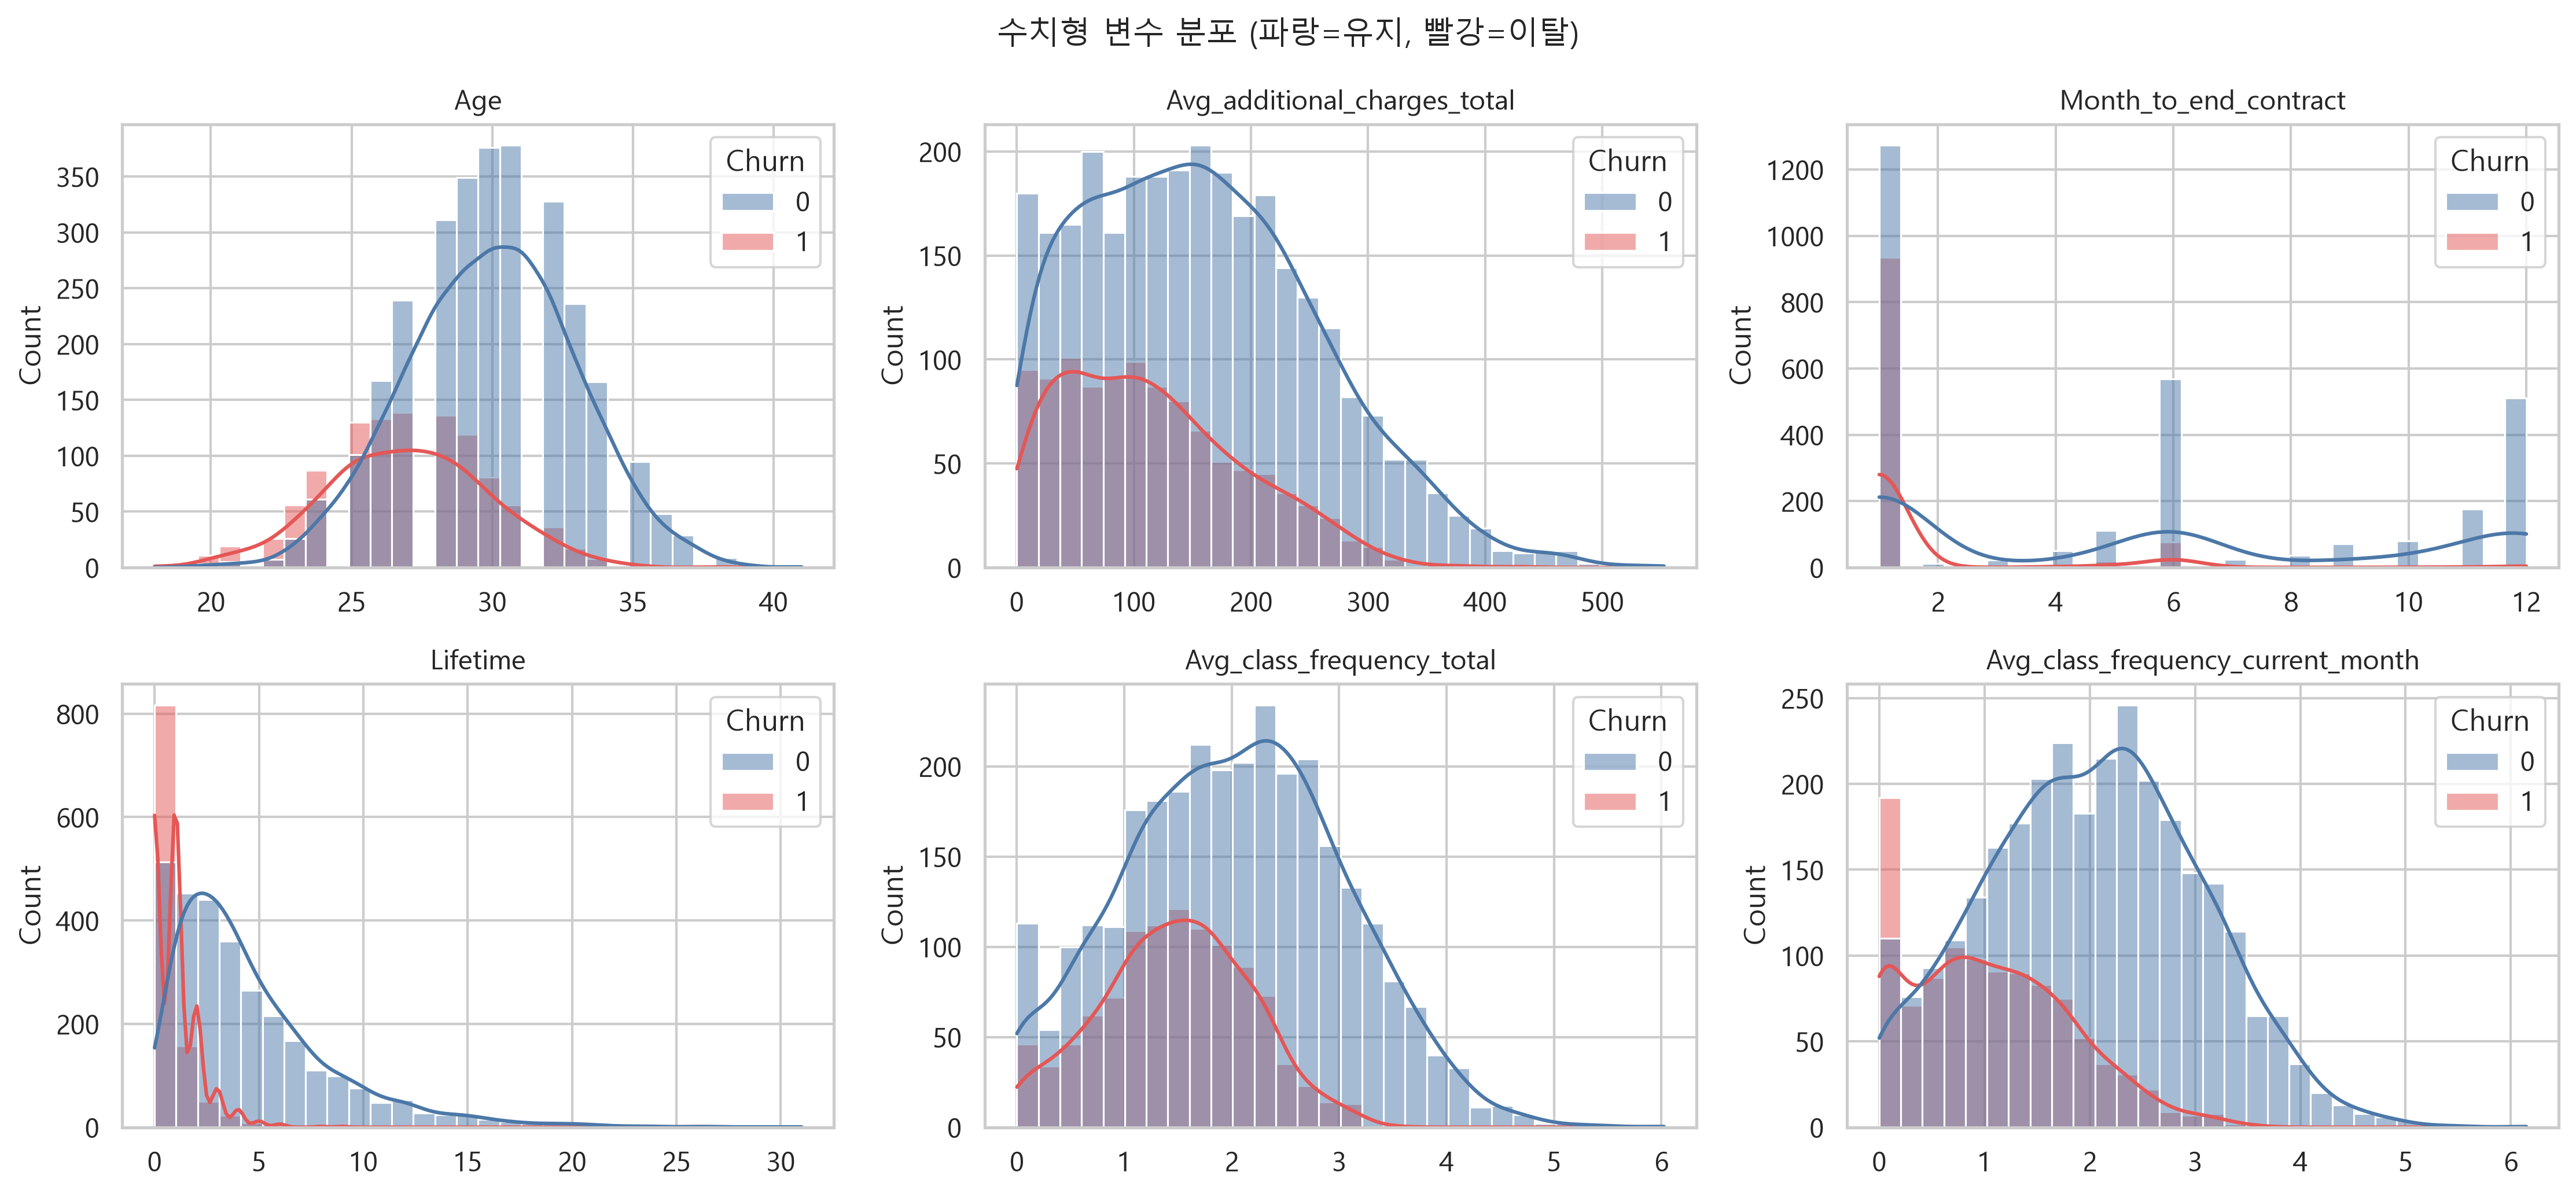

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for ax, col in zip(axes.ravel(), NUMERIC):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=True,
                 palette=["#4C78A8", "#E45756"], alpha=0.5, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")

fig.suptitle("수치형 변수 분포 (파랑=유지, 빨강=이탈)", fontsize=13)
plt.tight_layout()
plt.show()

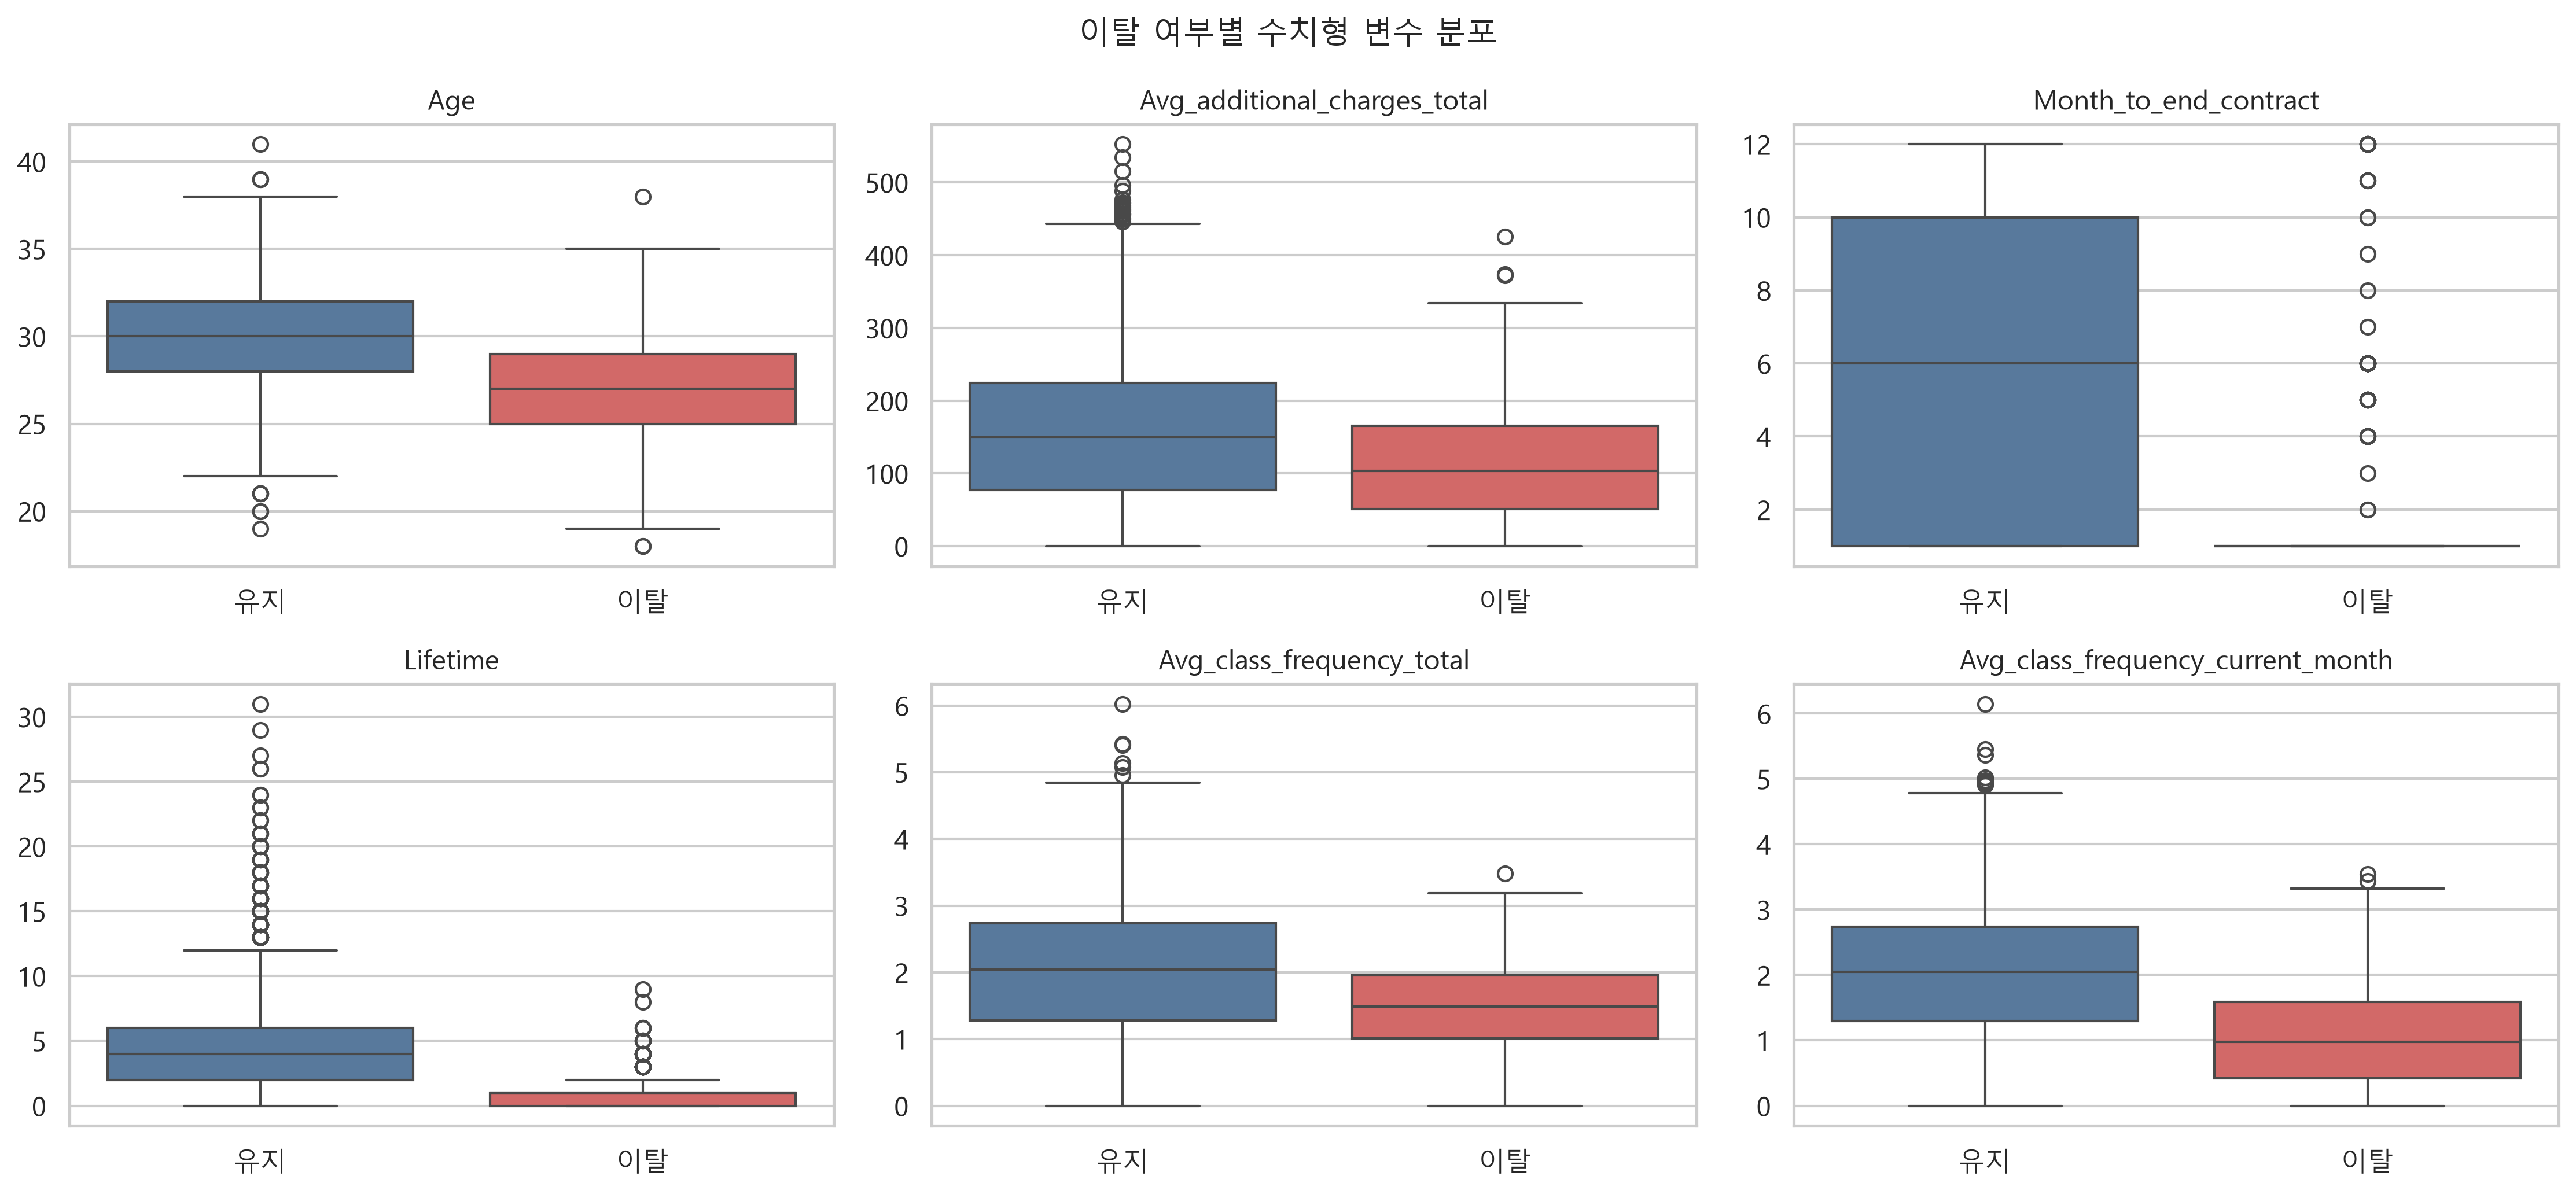

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for ax, col in zip(axes.ravel(), NUMERIC):
    sns.boxplot(data=df, x="Churn", y=col, hue="Churn",
                palette=["#4C78A8", "#E45756"], legend=False, ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["유지", "이탈"])

fig.suptitle("이탈 여부별 수치형 변수 분포", fontsize=13)
plt.tight_layout()
plt.show()

In [39]:
# 이탈 여부별 평균 비교
mean_by_churn = df.groupby("Churn")[NUMERIC].mean().T.round(3)
mean_by_churn.columns = ["유지(0)", "이탈(1)"]
mean_by_churn["차이"] = (mean_by_churn["이탈(1)"] - mean_by_churn["유지(0)"]).round(3)
mean_by_churn

,유지(0),이탈(1),차이
Age,29.977,26.990,-2.987
Avg_additional_charges_total,158.446,115.083,-43.363
Month_to_end_contract,5.283,1.663,-3.620
Lifetime,4.712,0.991,-3.721
Avg_class_frequency_total,2.025,1.475,-0.550
Avg_class_frequency_current_month,2.028,1.045,-0.983


## 5. 이진 / 범주형 변수별 이탈률

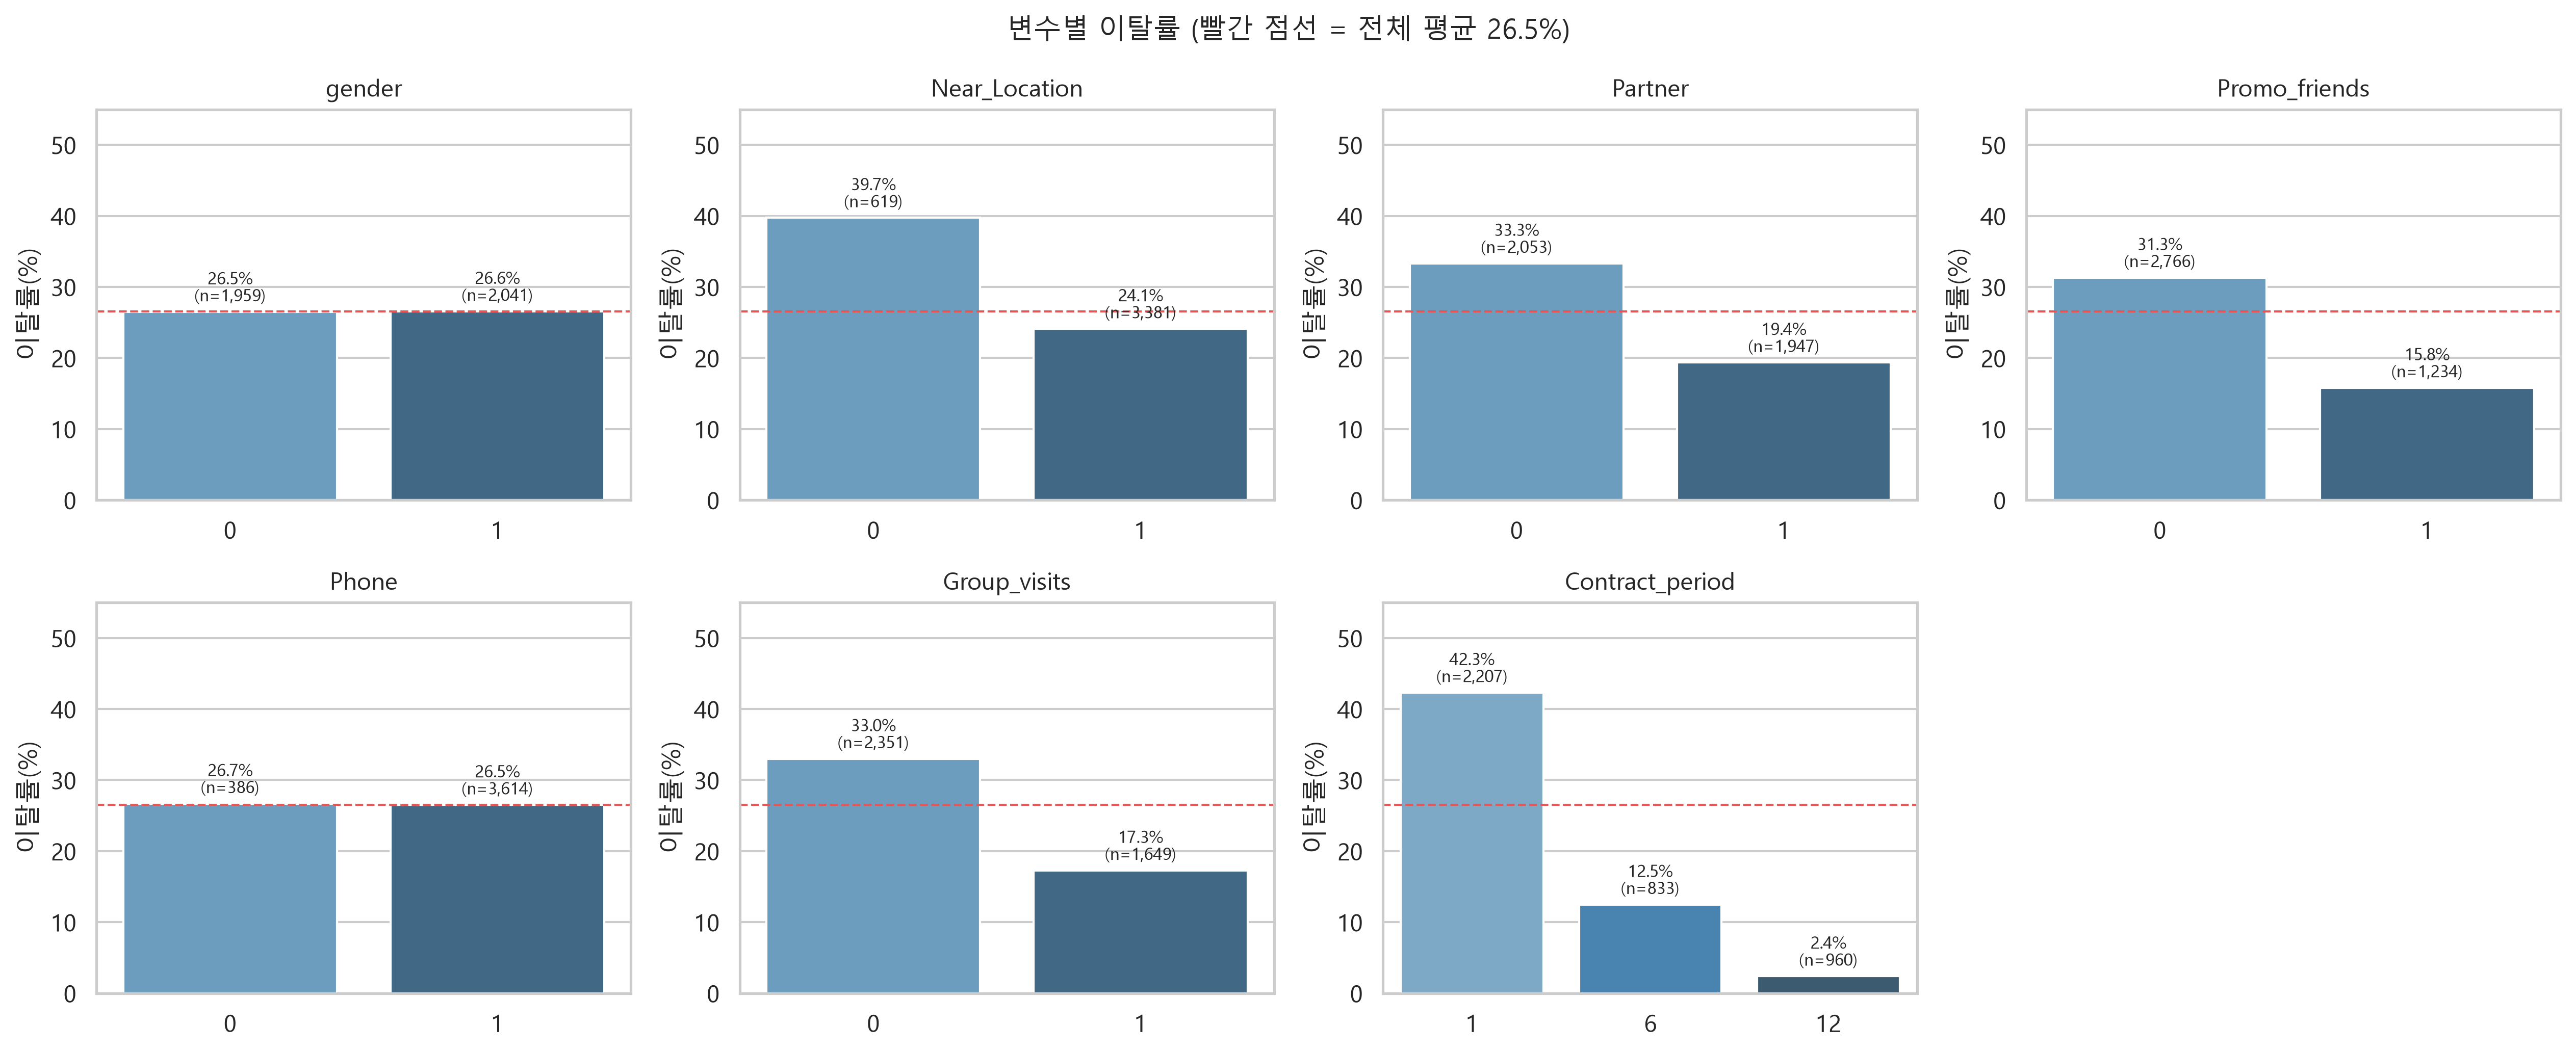

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
overall = df["Churn"].mean() * 100

for ax, col in zip(axes.ravel(), BINARY + CATEGORICAL):
    rate = df.groupby(col)["Churn"].agg(["count", "mean"])
    rate["mean"] *= 100

    sns.barplot(x=rate.index.astype(str), y=rate["mean"],
                hue=rate.index.astype(str), palette="Blues_d",
                legend=False, ax=ax)
    ax.axhline(overall, color="#E45756", linestyle="--", linewidth=1)

    for i, (v, n) in enumerate(zip(rate["mean"], rate["count"])):
        ax.text(i, v + 1, f"{v:.1f}%\n(n={n:,})", ha="center", va="bottom", fontsize=8)

    ax.set_title(col, fontsize=11)
    ax.set_ylabel("이탈률(%)")
    ax.set_xlabel("")
    ax.set_ylim(0, 55)

axes.ravel()[-1].axis("off")
fig.suptitle(f"변수별 이탈률 (빨간 점선 = 전체 평균 {overall:.1f}%)", fontsize=13)
plt.tight_layout()
plt.show()

In [41]:
# 표로도 확인
rows = []
for col in BINARY + CATEGORICAL:
    g = df.groupby(col)["Churn"].agg(["count", "mean"])
    for idx, r in g.iterrows():
        rows.append({
            "변수": col,
            "값": idx,
            "인원": int(r["count"]),
            "이탈률(%)": round(r["mean"] * 100, 2),
        })

rate_table = pd.DataFrame(rows)
rate_table["격차(%p)"] = rate_table.groupby("변수")["이탈률(%)"].transform(
    lambda s: round(s.max() - s.min(), 2)
)
rate_table.sort_values(["격차(%p)", "변수"], ascending=[False, True], ignore_index=True)

,변수,값,인원,이탈률(%),격차(%p)
0,Contract_period,1,2207,42.32,39.92
1,Contract_period,6,833,12.48,39.92
2,Contract_period,12,960,2.40,39.92
3,Group_visits,0,2351,33.01,15.73
4,Group_visits,1,1649,17.28,15.73
5,Near_Location,0,619,39.74,15.63
6,Near_Location,1,3381,24.11,15.63
7,Promo_friends,0,2766,31.31,15.51
8,Promo_friends,1,1234,15.80,15.51
9,Partner,0,2053,33.32,13.96


## 6. 상관관계 및 다중공선성

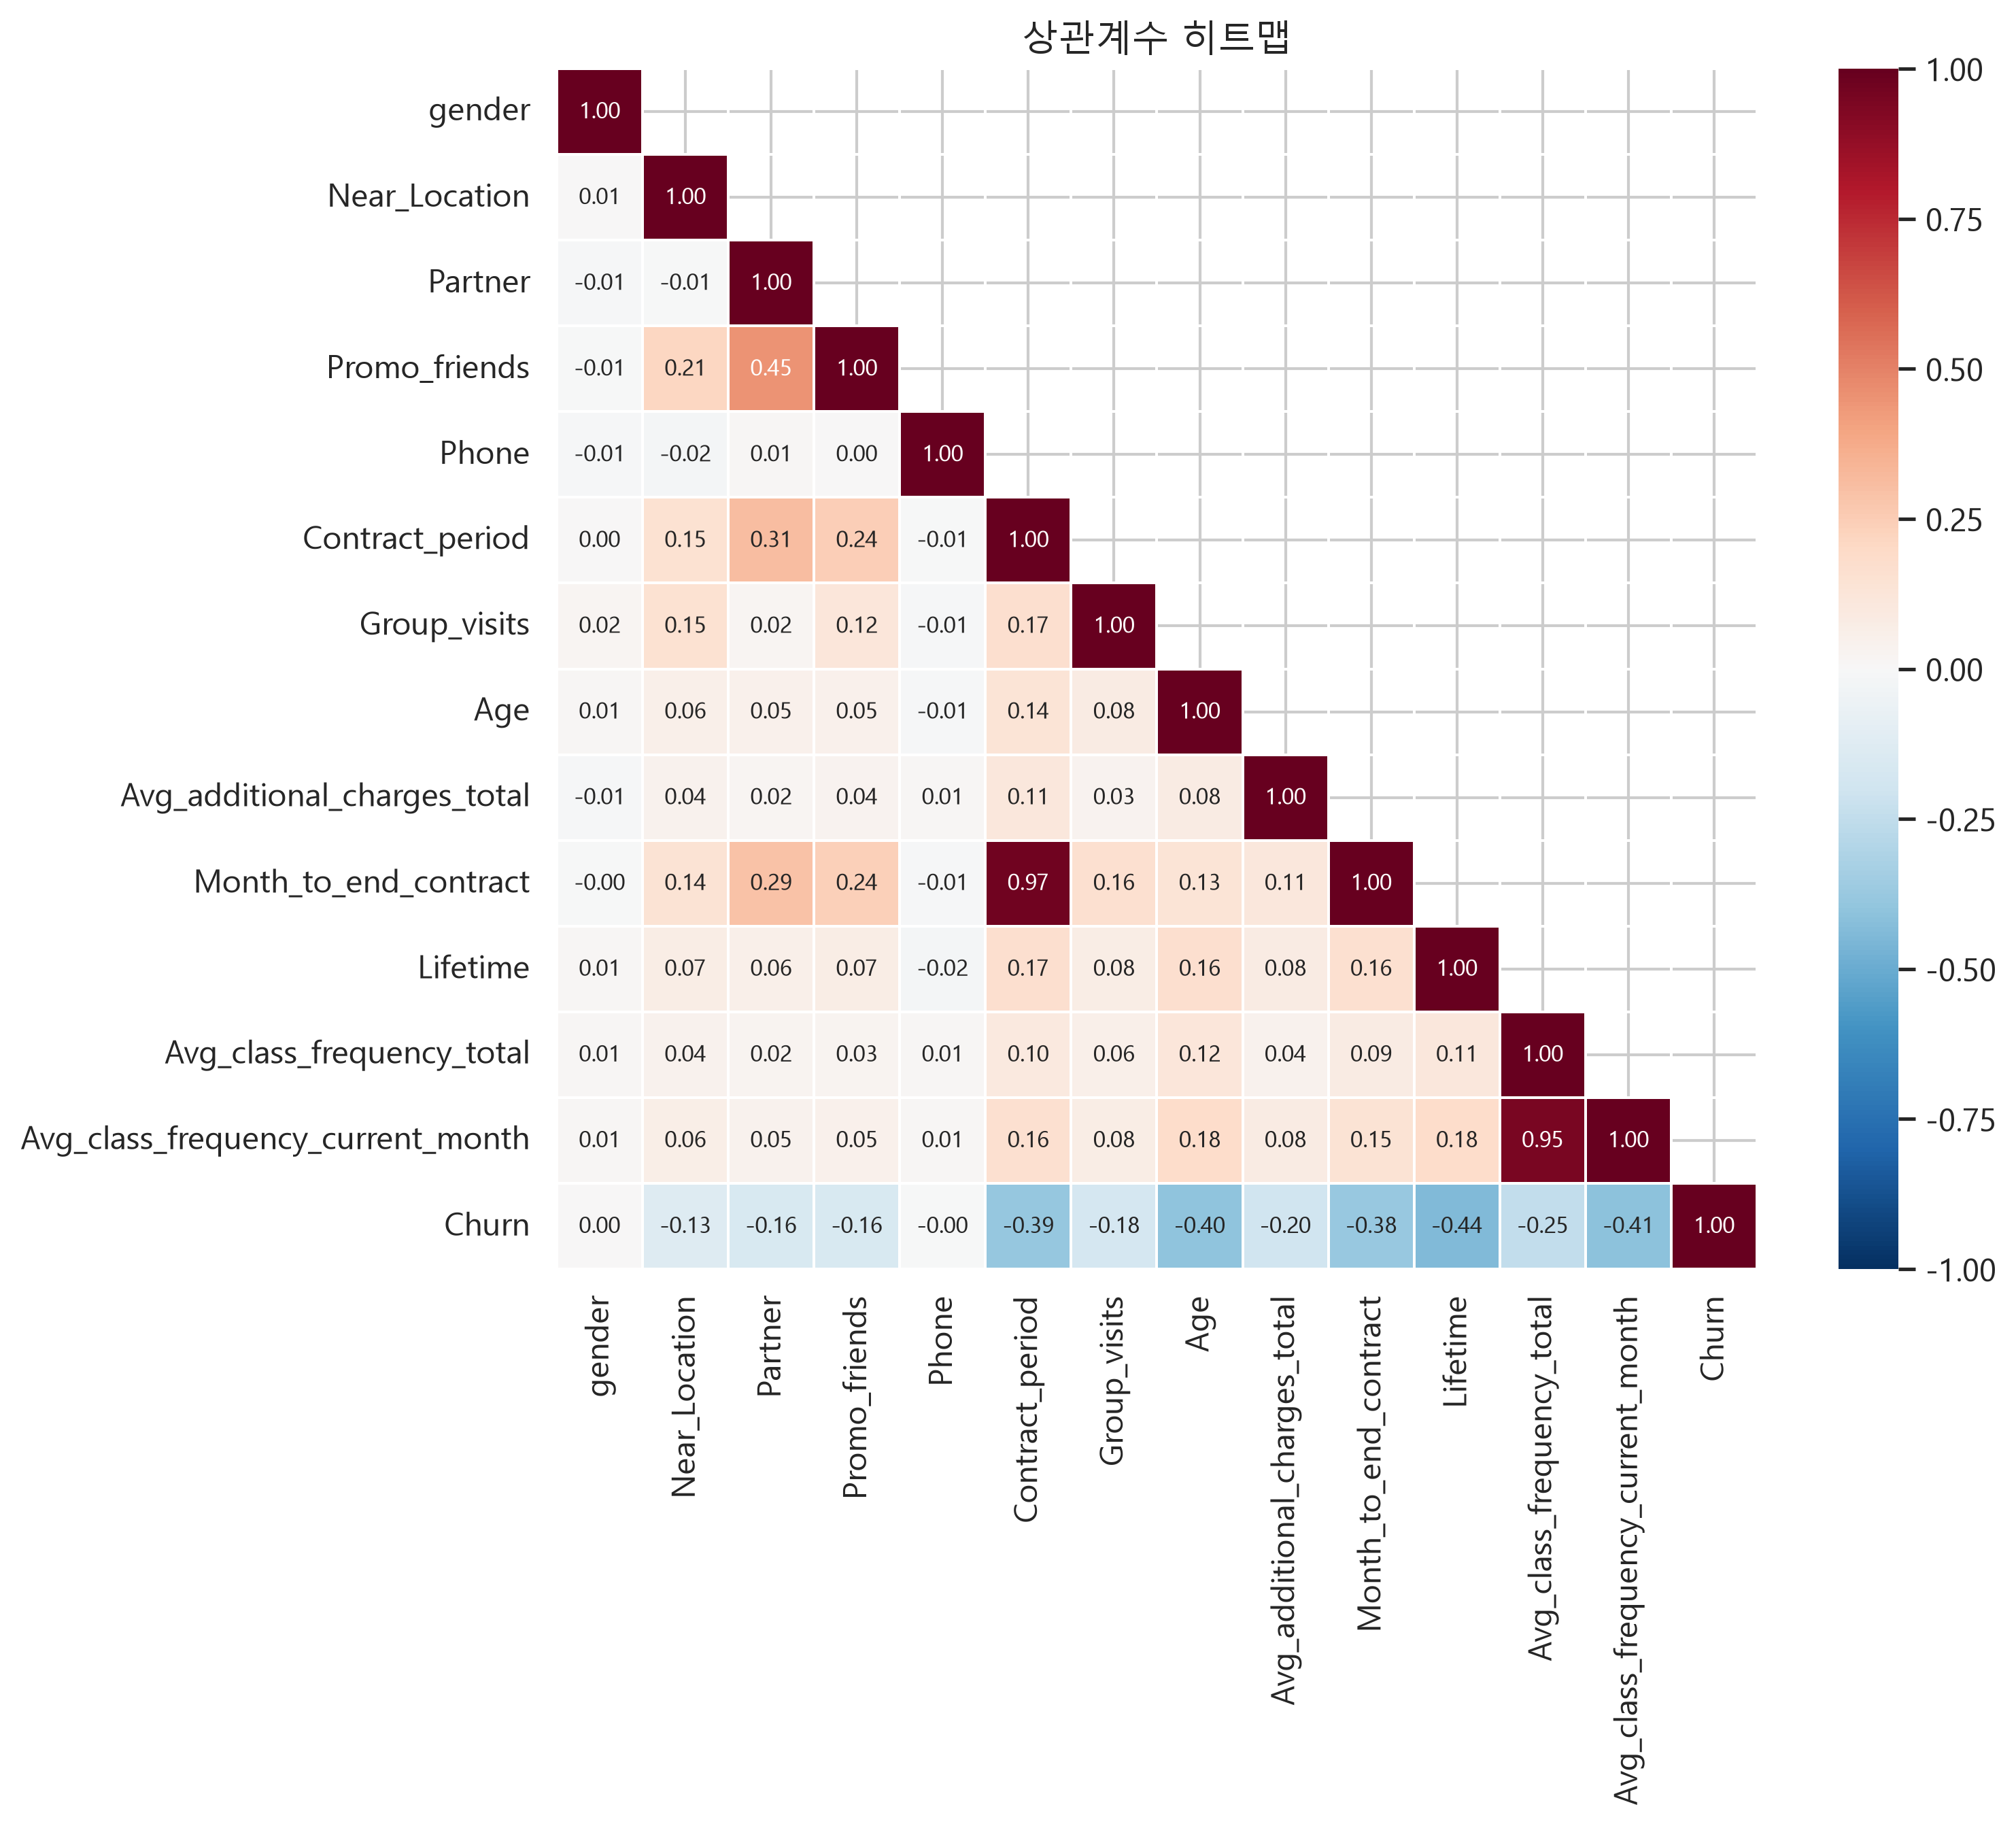

In [42]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, annot_kws={"size": 8}, ax=ax)
ax.set_title("상관계수 히트맵", fontsize=13)
plt.tight_layout()
plt.show()

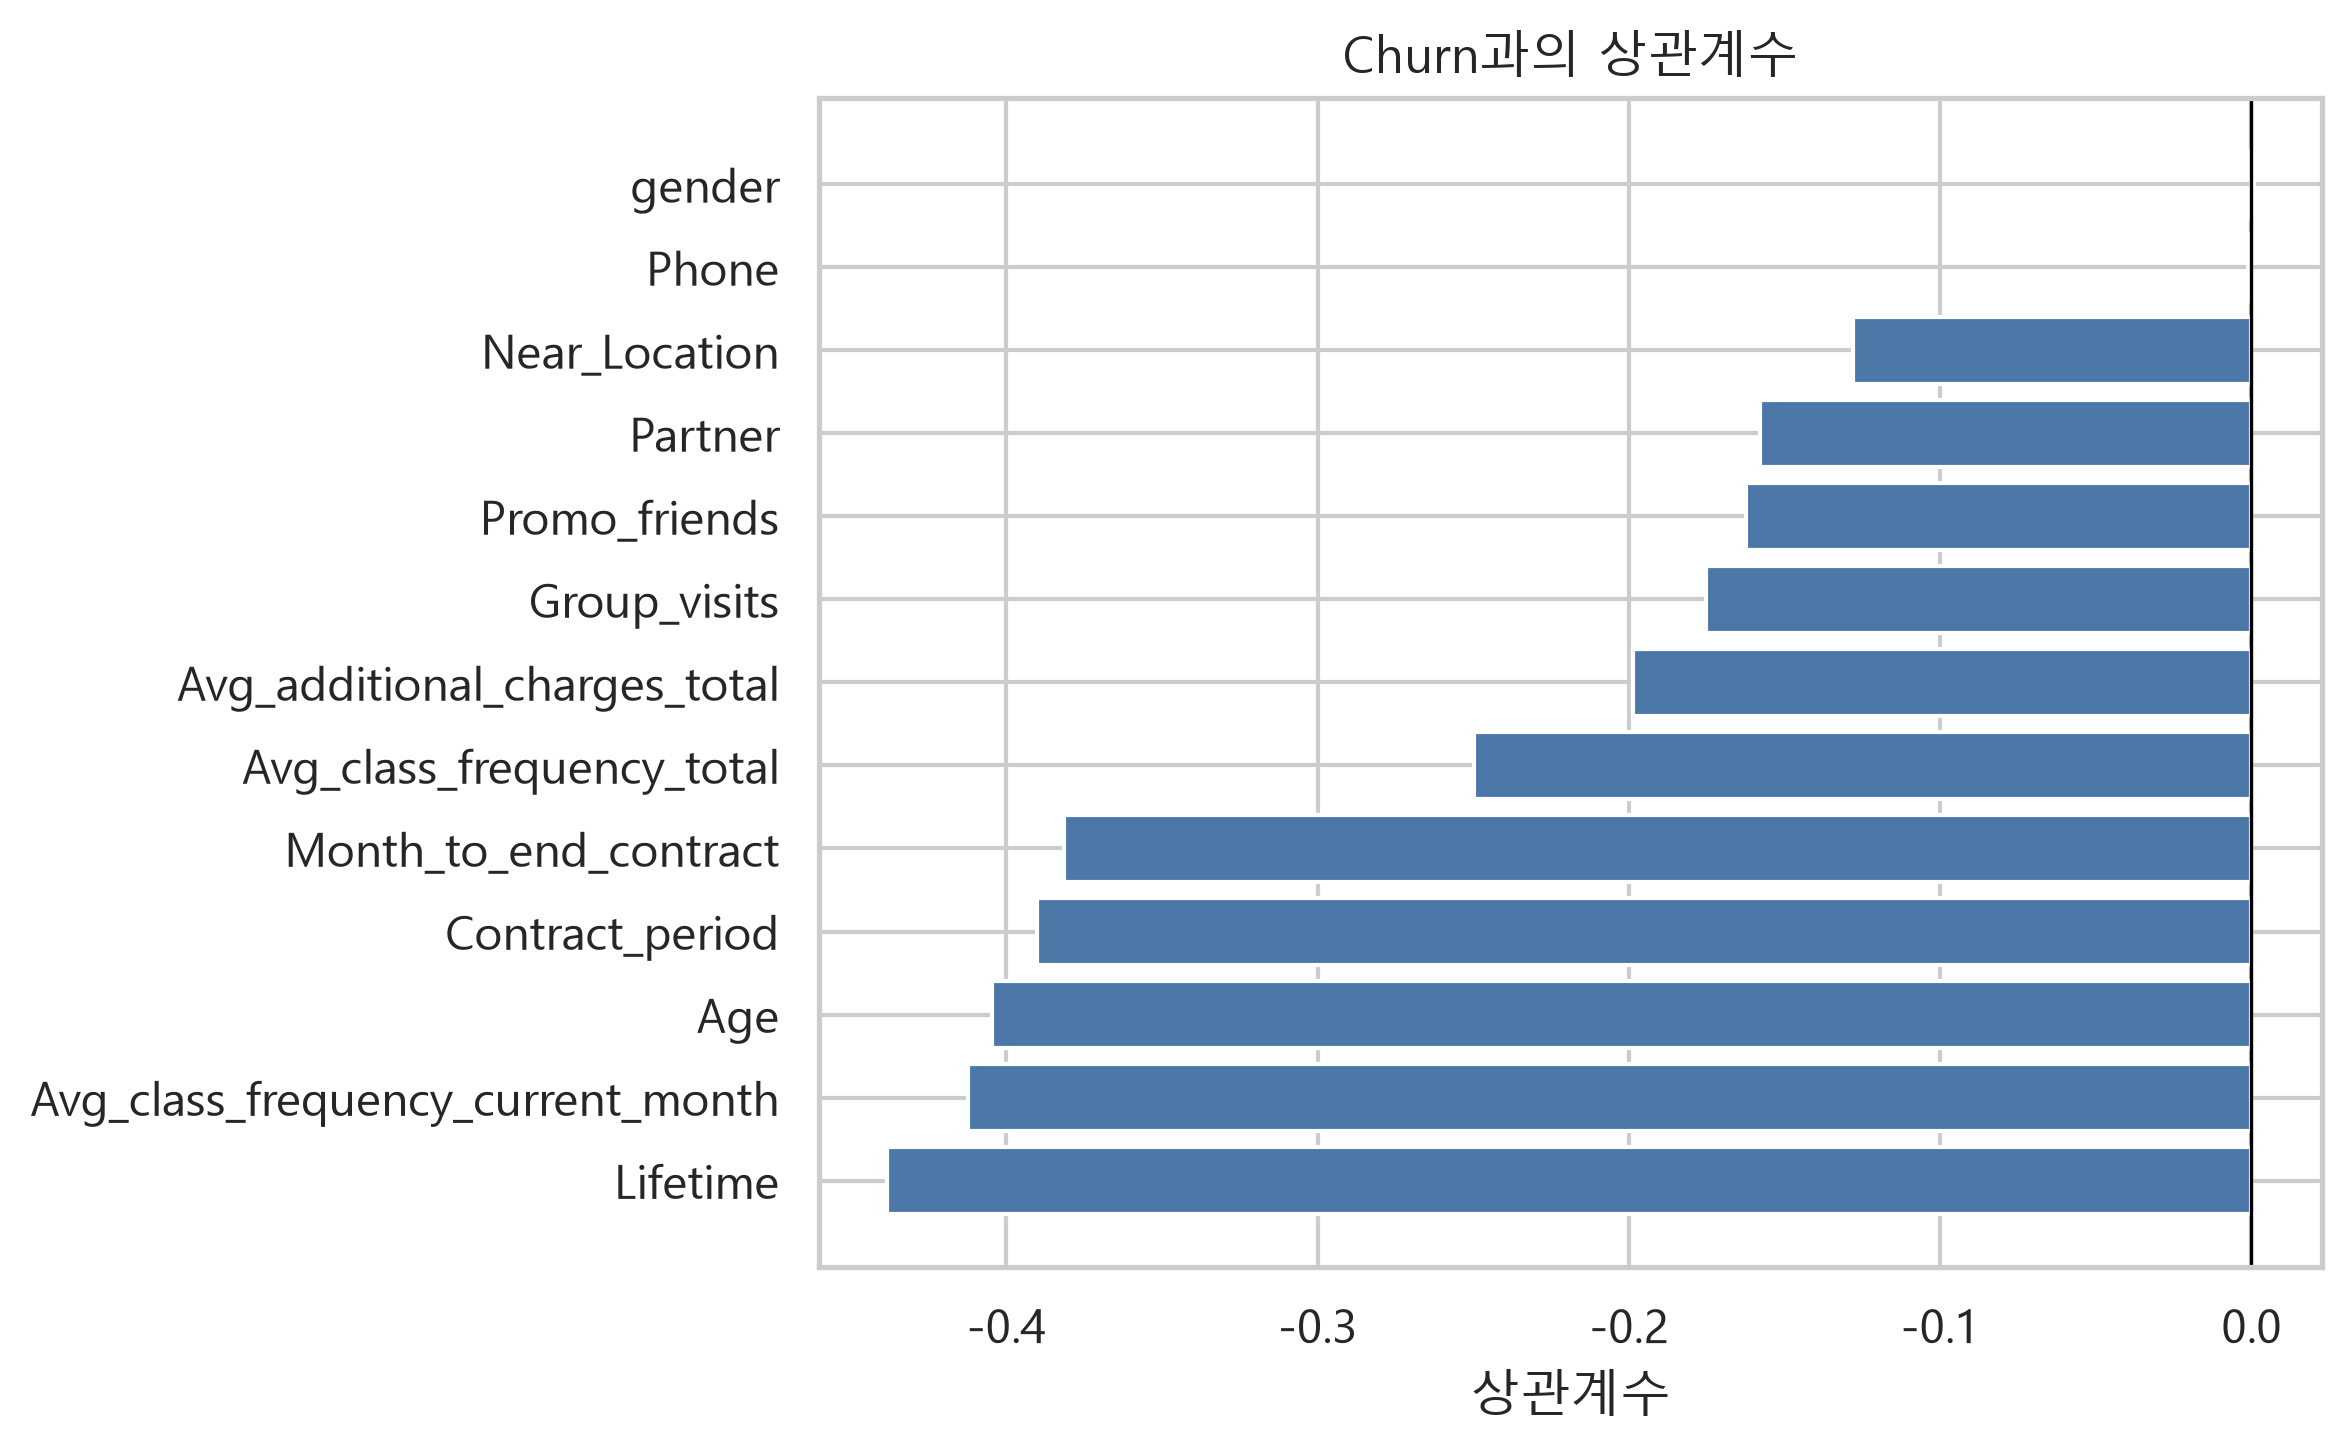

gender                               0.001
Phone                               -0.001
Near_Location                       -0.128
Partner                             -0.158
Promo_friends                       -0.162
Group_visits                        -0.175
Avg_additional_charges_total        -0.199
Avg_class_frequency_total           -0.250
Month_to_end_contract               -0.381
Contract_period                     -0.390
Age                                 -0.405
Avg_class_frequency_current_month   -0.412
Lifetime                            -0.438
Name: Churn, dtype: float64

In [43]:
churn_corr = corr["Churn"].drop("Churn").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#E45756" if v > 0 else "#4C78A8" for v in churn_corr]
ax.barh(churn_corr.index, churn_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Churn과의 상관계수")
ax.set_xlabel("상관계수")
plt.tight_layout()
plt.show()

churn_corr.sort_values(ascending=False).round(3)

In [44]:
# 다중공선성: 설명변수 간 |r| >= 0.5 쌍
c = corr.drop(index="Churn", columns="Churn").abs()
pairs = []
for i, a in enumerate(c.columns):
    for b in c.columns[i + 1:]:
        if c.loc[a, b] >= 0.5:
            pairs.append({"변수1": a, "변수2": b, "상관계수": round(c.loc[a, b], 3)})

pd.DataFrame(pairs).sort_values("상관계수", ascending=False, ignore_index=True)

,변수1,변수2,상관계수
0,Contract_period,Month_to_end_contract,0.973
1,Avg_class_frequency_total,Avg_class_frequency_current_month,0.953


## 7. 추가 확인 — 신규 회원과 계약 기간

,인원,이탈률(%)
Lifetime_bin,,
0개월(신규),487,82.75
1개월,843,49.11
2~3개월,1100,18.82
4~6개월,876,4.00
7개월+,694,0.29


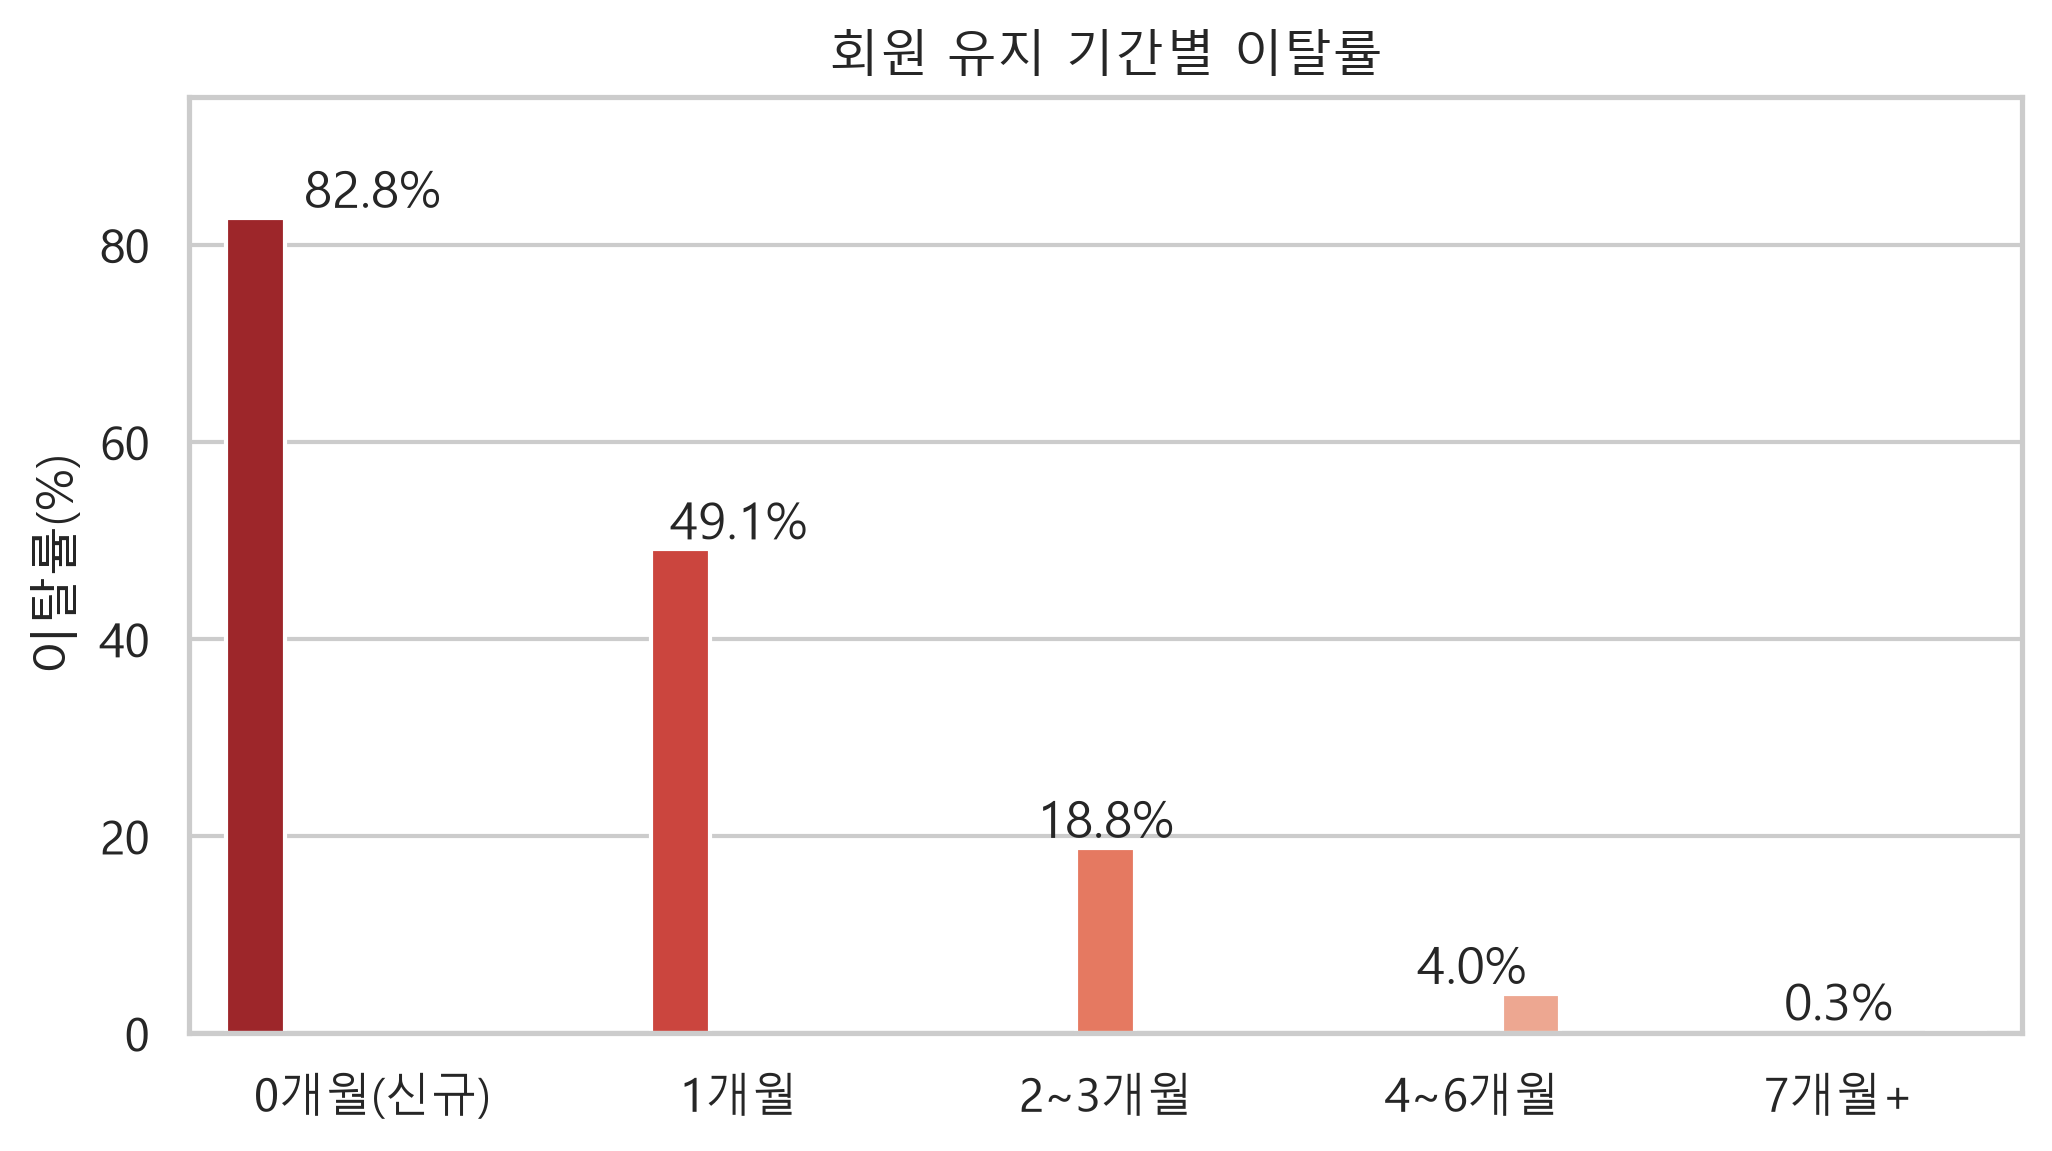

In [45]:
# Lifetime 구간별 이탈률
bins = [-0.1, 0.5, 1.5, 3.5, 6.5, np.inf]
labels = ["0개월(신규)", "1개월", "2~3개월", "4~6개월", "7개월+"]
df_tmp = df.assign(Lifetime_bin=pd.cut(df["Lifetime"], bins=bins, labels=labels))

lifetime_rate = df_tmp.groupby("Lifetime_bin", observed=True)["Churn"].agg(["count", "mean"])
lifetime_rate["mean"] = (lifetime_rate["mean"] * 100).round(2)
lifetime_rate.columns = ["인원", "이탈률(%)"]

display(lifetime_rate)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=lifetime_rate.index, y=lifetime_rate["이탈률(%)"],
            hue=lifetime_rate.index, palette="Reds_r", legend=False, ax=ax)
for i, v in enumerate(lifetime_rate["이탈률(%)"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")
ax.set_title("회원 유지 기간별 이탈률")
ax.set_ylabel("이탈률(%)")
ax.set_xlabel("")
ax.set_ylim(0, 95)
plt.tight_layout()
plt.show()

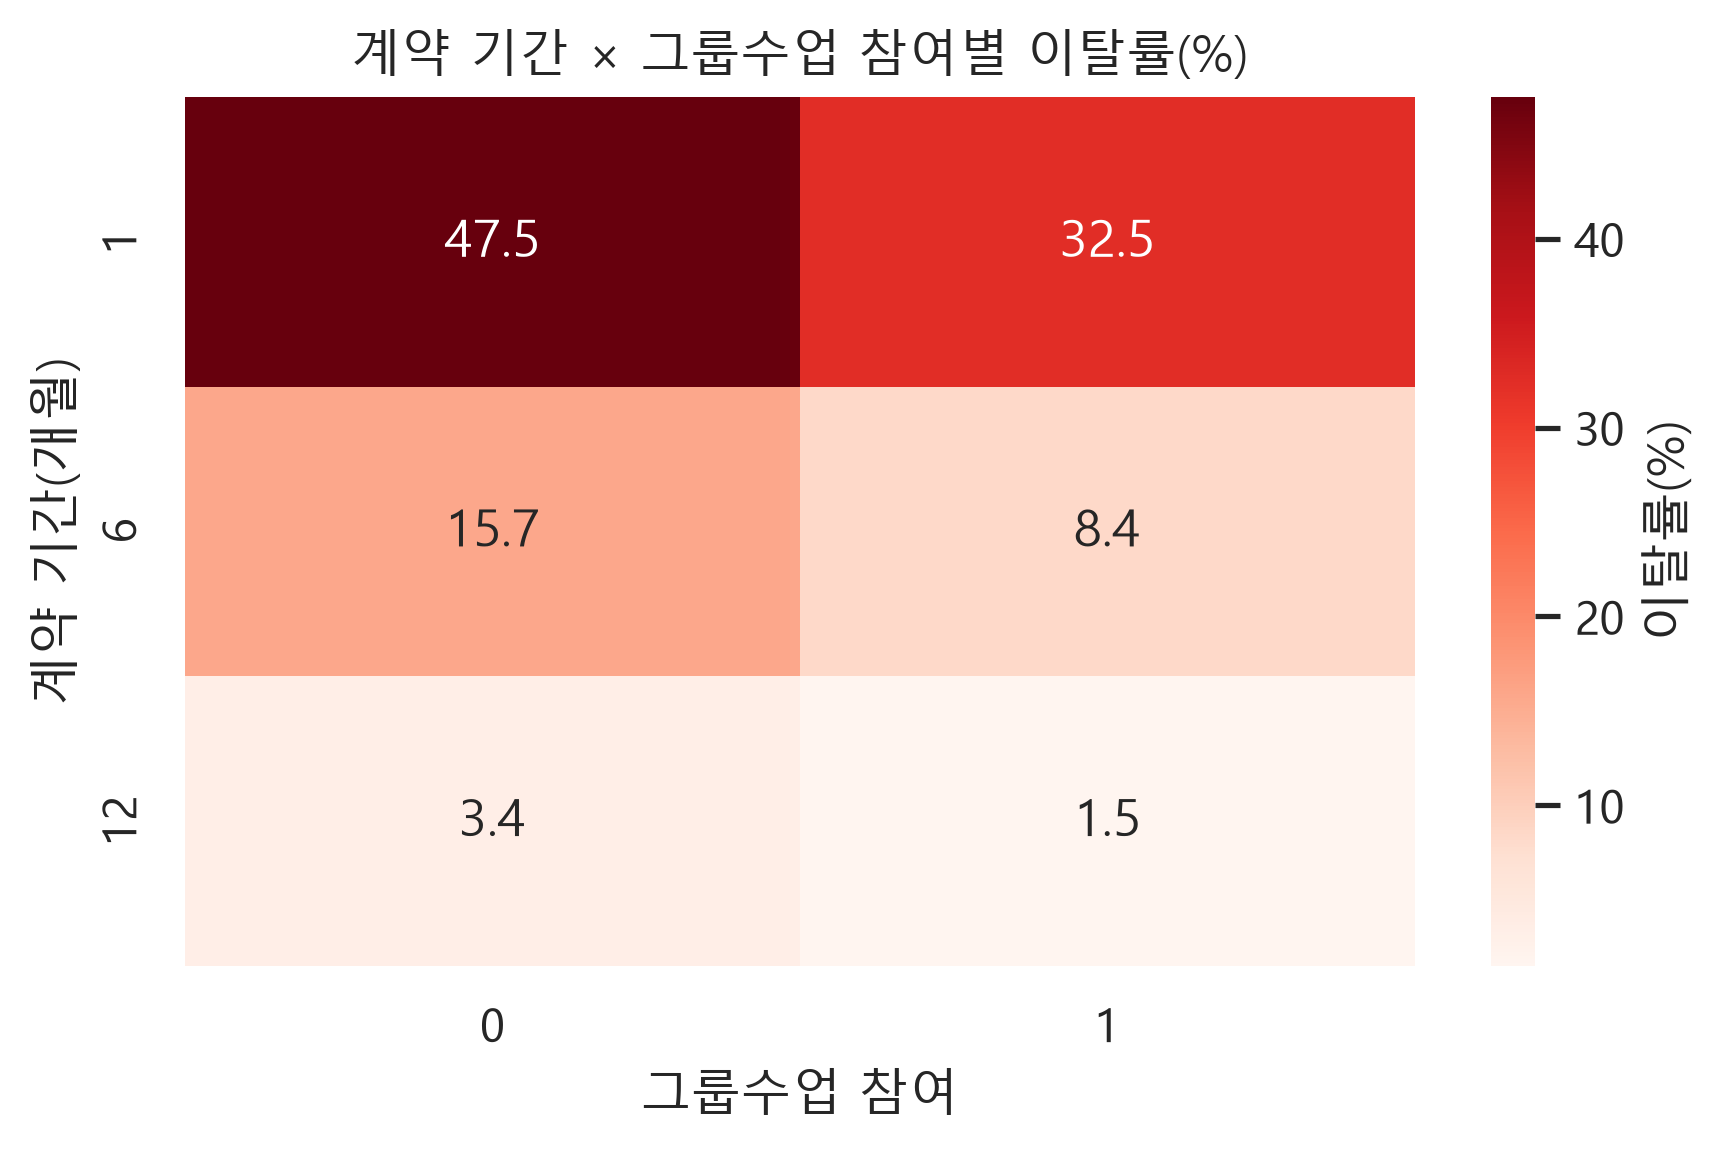

Group_visits,0,1
Contract_period,,
1,47.48,32.45
6,15.70,8.42
12,3.43,1.53


In [46]:
# 계약 기간 x 그룹수업 참여 교차 이탈률
cross = df.pivot_table(index="Contract_period", columns="Group_visits",
                       values="Churn", aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cross.round(1), annot=True, fmt=".1f", cmap="Reds",
            cbar_kws={"label": "이탈률(%)"}, ax=ax)
ax.set_title("계약 기간 × 그룹수업 참여별 이탈률(%)")
ax.set_xlabel("그룹수업 참여")
ax.set_ylabel("계약 기간(개월)")
plt.tight_layout()
plt.show()

cross.round(2)

In [47]:
# 직전 달 방문이 0인 비율 (Churn 정의 확인용)
zero_visit = df.groupby("Churn")["Avg_class_frequency_current_month"].apply(
    lambda s: (s == 0).mean() * 100
).round(2)
zero_visit.index = ["유지(0)", "이탈(1)"]
zero_visit.name = "직전 달 방문 0인 비율(%)"
zero_visit

유지(0)     1.60
이탈(1)    12.63
Name: 직전 달 방문 0인 비율(%), dtype: float64

## 8. 기초 EDA 정리

**데이터 품질**
- 4,000행 × 14열, 결측치 0, 중복행 0 — 전처리 부담 거의 없음
- 모든 변수가 이미 숫자 인코딩되어 별도 인코딩 불필요
- 스케일 차이 큼(`Avg_additional_charges_total` 최대 552 vs 나머지 한 자릿수)
  → 로지스틱회귀·SVM 등 거리 기반 모델은 스케일링 필수, 트리 계열은 불필요

**타깃**
- 이탈률 26.5% (2.8 : 1 불균형) → accuracy 대신 ROC-AUC / Recall / F1 사용

**이탈과 강하게 연관된 변수**
- `Lifetime` (-0.44), `Avg_class_frequency_current_month` (-0.41), `Age` (-0.41),
  `Contract_period` (-0.39), `Month_to_end_contract` (-0.38)
- 계약 기간별 이탈률: 1개월 **42.3%** / 6개월 12.5% / 12개월 **2.4%**
- 유지 기간 0개월(신규) 집단의 이탈률이 압도적으로 높음 → 조기 이탈이 핵심 문제

**신호가 없는 변수**
- `gender` (r=0.001), `Phone` (r=-0.001) — 이탈률 차이 0.1%p 미만. 피처 제거 후보

**모델링 시 주의점**
1. **다중공선성 2쌍**
   - `Contract_period` ↔ `Month_to_end_contract` (r=0.97, 정의상 필연)
   - `Avg_class_frequency_total` ↔ `Avg_class_frequency_current_month` (r=0.95)
   - 회귀 계수 해석이 왜곡되므로 쌍에서 하나만 쓰거나 파생변수로 통합
     (예: 계약 소진율 = `1 - Month_to_end_contract / Contract_period`)
2. **`Avg_class_frequency_current_month`의 선행지표 성격**
   - 이탈자 중 직전 달 방문이 0인 비율은 12.6%뿐이라 직접적 누수는 아니지만,
     이탈 직전 이용 감소를 반영 → 포함/제외 두 시나리오 비교 실험 가치 있음

**EDA가 시사하는 방향**

세 가지 사실이 이후 분석 설계를 좌우한다.

1. 이탈은 **가입 직후에 집중**된다 (0개월 82.8% → 7개월+ 0.3%)
   → 단순히 "누가 이탈하는가"보다 "**언제** 이탈하는가"가 실무적으로 더 중요
2. 이탈률을 가르는 변수 중 상당수가 **개입 가능한 항목**이다
   (계약 기간, 그룹수업, 친구추천, 제휴사) → 솔루션으로 연결 가능
3. 고객은 이탈/유지 이분법보다 **위험도 스펙트럼**에 가깝다
   (1개월+그룹수업X 47.5% ↔ 12개월+그룹수업O 1.5%) → 중간 위험군 식별 필요

다만 계획을 확정하기 전에 확인이 필요한 것이 있다.
어떤 변수를 쓰고 버릴지, 딥러닝을 도입할지는 **추측이 아니라 실험으로** 정해야 한다.
9번 섹션에서 이를 검증하고, 10번 섹션에 최종 트랙 설계를 정리한다.

## 9. 피처 선택 사전 검증

계획을 확정하기 전에 세 가지를 실험으로 확인했다.

**피처 선택**
1. `gender` / `Phone` 을 빼야 하는가? → 9.1
2. `Age` 를 빼야 하는가? → 9.2
3. 딥러닝을 도입할 여지가 있는가? → 9.3
4. 파생변수를 **언제** 넣어야 하는가? → 9.4

**모델링 전제**

5. 누수 의심 변수를 빼도 예측이 되는가? → 9.5 ★
6. 이상치를 제거해야 하는가? → 9.6
7. `Age` 효과가 `Lifetime`의 대리변수는 아닌가? → 9.7
8. 군집 개수 k는 몇이 적절한가? → 9.8
9. 불균형 처리가 필요한가? → 9.9
10. 데이터가 충분한가? → 9.10

**실험 조건**: `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`, 지표 ROC-AUC.
아래 수치는 이 노트북과 별도로 실행한 결과를 정리한 것이다.

### 9.1 `gender` / `Phone` — 제거 확정

#### 통계 검정: 이탈과 독립인가?

| 변수 | 값=0 이탈률 (95% CI) | 값=1 이탈률 (95% CI) | 카이제곱 p |
|---|---|---|---|
| `gender` | 26.49% [24.59, 28.49] | 26.56% [24.68, 28.51] | **0.9929** |
| `Phone` | 26.68% [22.52, 31.31] | 26.51% [25.09, 27.97] | **0.9890** |
| `Group_visits` *(대조군)* | 33.01% | 17.28% | **<0.0001** |

p ≈ 0.99 는 귀무가설(독립)과 거의 완벽히 일치한다는 뜻이며, 두 집단의 신뢰구간도 사실상 겹친다.
유의한 변수인 `Group_visits`와 대비하면 차이가 분명하다.

#### 제거 시 성능 변화 — 오히려 **상승**

| 모델 | 전체(13) | gender 제외 | Phone 제외 | 둘 다 제외(11) |
|---|---|---|---|---|
| RandomForest | 0.9723 | +0.0004 | +0.0010 | **+0.0015** |
| XGBoost | 0.9822 | -0.0001 | +0.0002 | **+0.0005** |
| LogisticRegression | 0.9766 | +0.0001 | +0.0000 | **+0.0002** |

정보가 없을 뿐 아니라 분할 후보로 들어가 **잡음으로 작용**한다는 뜻이다.

#### 로지스틱 회귀 계수 유의성 — 13개 중 최하위 2개

| 변수 | 표준화 계수 | p-value |
|---|---|---|
| `gender` | -0.0033 | **0.9624** |
| `Phone` | -0.0046 | **0.9514** |

#### 군집화에서 효과가 가장 크다

| 피처셋 | 실루엣 | 군집별 이탈률 | 격차 |
|---|---|---|---|
| **9축 (제외)** | **0.1886** | 10.5 / 33.6 / 39.9% | 29.4%p |
| 11축 (포함) | 0.1538 | 10.6 / 33.4 / 39.9% | 29.3%p |

실루엣이 **23% 개선**되면서 이탈률 분리도는 그대로다. 정보 손실 없이 군집 품질만 좋아진다.

#### 숨은 상호작용도 없음

"단독으론 무의미해도 조합하면 의미가 생기지 않을까"를 확인했으나, `gender`는 어떤 변수와
교차해도 이탈률 차이가 **2%p 이내**였다 (`Contract_period` 2.07%p, `Group_visits` 0.86%p,
`Promo_friends` 0.57%p).

> **결론**: 트랙 A에서는 성능 영향이 ±0.001 수준이라 넣어도 무방하지만,
> 해석 명료성을 위해 제거한다. **트랙 C(군집화)에서는 필수 제거.**
>
> 참고로 `Phone`은 90.4%가 1인 준-상수 변수라 애초에 정보량이 거의 없다.
>
> 💡 **성별이 이탈과 무관하다는 것 자체가 보고서에 쓸 결과다.**
> 리텐션 캠페인에서 성별 타깃팅이 불필요하다는 실무적 시사점이 된다.

### 9.2 `Age` — 유지 확정

`gender`/`Phone`과 정반대 결론이다.

#### 제거 시 성능 하락

| 모델 | 전체(13) | Age 제외(12) | 변화 |
|---|---|---|---|
| LogisticRegression | 0.9766 | 0.9664 | **-0.0102** |
| RandomForest | 0.9723 | 0.9636 | -0.0088 |
| MLP(64,32) | 0.9722 | 0.9634 | -0.0088 |
| XGBoost | 0.9822 | 0.9775 | -0.0046 |

전 모델에서 일관되게 하락한다. 낙폭이 작아 보이는 것은 AUC가 이미 0.98 천장이기 때문이다.

#### Permutation Importance (XGBoost, ROC-AUC 기준)

| 순위 | 변수 | 중요도 |
|---|---|---|
| 1 | `Avg_class_frequency_current_month` | 0.2347 |
| 2 | `Avg_class_frequency_total` | 0.1123 |
| 3 | `Lifetime` | 0.0785 |
| **4** | **`Age`** | **0.0117** |
| 5 | `Contract_period` | 0.0053 |
| … | | |
| 9 | `gender` | 0.0004 |
| 12 | `Phone` | 0.0001 |

`Age`는 제거 후보인 `gender`·`Phone`보다 **30~100배** 기여한다.

#### 연령대별 이탈률 — 매우 뚜렷한 단조 감소

| 연령 | 18~24 | 25~27 | 28~30 | 31~33 | 34+ |
|---|---|---|---|---|---|
| 인원 | 305 | 909 | 1,372 | 1,051 | 363 |
| 이탈률 | **66.2%** | 44.2% | 24.5% | 10.4% | **3.3%** |

20대 초반과 34세 이상의 이탈률 차이가 **20배**다.

> **결론**: 트랙 A·B·C 전부에서 유지. 트랙 D에서는 레버가 아니라 **타깃팅 기준**으로 쓴다.
>
> ⚠ 공정성 참고 — 연령 기반 **차등 가격**은 논란 소지가 있으나,
> **리텐션 개입 대상 선정**은 일반적으로 문제되지 않는다.

#### ⚠ 1위 변수에 대한 경고

`Avg_class_frequency_current_month`의 중요도(0.2347)가 2위의 **2배**다.
AUC 0.98이라는 비현실적으로 높은 성능이 사실상 이 변수 하나에서 나온다.

트랙 A에 넣은 **포함/제외 두 시나리오 비교**는 형식적 절차가 아니라 이 프로젝트의 핵심 검증이다.
제외 시 성능이 얼마나 떨어지는지가 "실제로 예측 가능한가"의 답이 된다.

### 9.3 딥러닝 — 비교군으로만 도입

이미 설치된 `sklearn.neural_network.MLPClassifier`로 검증했다 (torch 불필요).

| 모델 | ROC-AUC | F1 |
|---|---|---|
| **XGBoost** | **0.9822** (±0.0043) | **0.8931** |
| LogisticRegression | 0.9766 (±0.0039) | 0.8571 |
| MLP(128,64,32) | 0.9737 (±0.0053) | 0.8596 |
| RandomForest | 0.9723 (±0.0048) | 0.8433 |
| MLP(64,32) | 0.9722 (±0.0069) | 0.8573 |

**MLP는 XGBoost에 지고, 단순 로지스틱회귀에도 밀린다.**
층을 늘려도(64,32 → 128,64,32) AUC가 0.0015 오르는 데 그쳤고 표준편차는 더 크다.

#### 왜 불리한가

**4,000행 × 13개 정형 피처**는 딥러닝이 구조적으로 불리한 조건이다.
학습할 공간적·순차적 구조가 없고, 표본이 적어 파라미터를 채울 수 없다.
정형 데이터에서 트리 앙상블이 딥러닝을 앞선다는 것은 벤치마크로 잘 정리된 사실이며,
이 데이터에서도 그대로 재현된다.

#### 그래도 넣을 자리 — 비교군

`classification.py` 의 후보 모델에 MLP를 **비교군**으로 포함하고
*"딥러닝을 시도했으나 데이터 규모·구조상 XGBoost가 우세했다"* 를 근거와 함께 보고한다.
실패한 실험이 아니라 **모델 선정의 정당화**다. 비용도 0에 가깝다 (sklearn 내장, 학습 수 초).

#### 권하지 않는 것

| 항목 | 이유 |
|---|---|
| `torch` / `tensorflow` 도입 | 이 규모에서 얻을 것이 없음. `requirements.txt`는 **팀 공통 파일**이라 임의 수정 불가 |
| TabNet · FT-Transformer | 보통 수만 행 이상에서 의미가 생김 |
| 군집화용 Autoencoder | 9개 축을 압축할 이유가 없음 |

### 9.4 파생변수 — 베이스라인 **이후**에 검증한다

#### 결론: 파생변수를 먼저 넣으면 안 된다

**베이스라인은 파생변수의 가치를 재는 자(尺)다.** 자 없이 만든 파생변수는 좋은지 나쁜지 말할 수 없다.
아래 실험도 원본 베이스라인(①)이 있었기 때문에 "+0.0137"이라고 말할 수 있는 것이다.

#### 검증 대상

| 파생변수 | 정의 | 목적 |
|---|---|---|
| `계약소진율` | `1 - Month_to_end_contract / Contract_period` | `Contract_period` ↔ `Month_to_end_contract` (r=0.97) 통합 |
| `방문변화_차이` | `Avg_class_frequency_current_month - Avg_class_frequency_total` | 방문 빈도 2변수 (r=0.95) 통합 |

> **비율(÷)이 아니라 차이(−)를 쓴다.** `Avg_class_frequency_total == 0`인 고객이 **88명** 있어
> 비율은 0으로 나누기가 발생한다. 성능도 차이(0.9880)가 비율(0.9878)보다 근소하게 낫다.

#### 성능 비교 (ROC-AUC, 5-fold CV / 베이스라인 대비 변화)

| 피처셋 | LogReg | RandomForest | XGBoost |
|---|---|---|---|
| ① 베이스라인 (원본 11) | 0.9767 | 0.9737 | 0.9826 |
| ② +계약소진율 (추가) | -0.0000 | -0.0009 | -0.0002 |
| ③ 계약소진율로 **대체** | -0.0001 | +0.0013 | +0.0001 |
| ⑤ 방문변화_차이로 **대체** | -0.0003 | **+0.0137** | **+0.0053** |
| ⑦ 파생 2개로 **대체** | -0.0003 | **+0.0136** | **+0.0055** |

두 파생변수의 성격이 **정반대**다.

#### 계약소진율 — 예측엔 무용, 해석엔 필수

성능 기여가 +0.0001에 그친다. 분포가 한쪽에 몰려 있기 때문이다.

| 계약소진율 | 0.00 | 0.08 | 0.17 | 0.25 | 0.33+ |
|---|---|---|---|---|---|
| 인원 | **3,362 (84%)** | 181 | 205 | 73 | 179 |
| 이탈률 | 30.4% | 2.2% | 10.2% | 1.4% | ~7% |

대부분이 계약 직후라 `Month_to_end_contract == Contract_period`이고 소진율이 0에 몰린다.
로지스틱 계수도 **p=0.6325로 무의미**하다.

그러나 **다중공선성 해소에는 결정적이다.**

| 변수 | 원본 VIF | 파생 대체 후 VIF |
|---|---|---|
| `Contract_period` | **19.18** | **1.41** |
| `Month_to_end_contract` | 18.87 | (제거) |
| `Avg_class_frequency_current_month` | 12.51 | (제거) |
| `Avg_class_frequency_total` | 11.94 | 1.17 |

VIF가 19 → 1.4로 떨어지면서 **계수 해석이 완전히 달라진다.**
원본에서 `Contract_period`는 p=0.1063으로 **무의미하게 나왔으나**, 파생 대체 후 **p<0.0001로 유의**해진다.
계약 기간이 이탈의 최대 요인이라는 EDA 결과(1개월 42.3% ↔ 12개월 2.4%)와 비로소 일치한다.

#### 방문변화_차이 — 트리엔 큰 이득, 선형 모델엔 0

RF +0.0137, XGB +0.0053인데 로지스틱은 -0.0003이다. 우연이 아니라 이론대로다.

- `current - total`은 이미 모델에 있는 두 변수의 **선형 결합** → 선형 모델엔 새 정보가 0
- 트리는 축에 수직인 분할만 하므로 이 차이를 스스로 만들지 못함 → 크게 이득

#### 주의 3가지

1. **"추가"가 아니라 "대체"로 쓴다.**
   ②(추가)는 RF에서 -0.0009로 오히려 떨어지고 ⑦(대체)은 +0.0136이다.
   원본을 남기면 중복 정보가 잡음이 된다.
2. **`방문변화_차이`의 이득은 누수 의심 변수 위에 얹혀 있다.**
   `current - total`이므로 `Avg_class_frequency_current_month`를 그대로 포함한다.
   → **`current_month` 제외 시나리오에서는 이 파생변수가 성립하지 않는다.** 별도 설계 필요.
3. **`계약소진율`은 성능이 아니라 해석을 위해 채택한다.**
   보고서에 "성능을 올렸다"가 아니라 "다중공선성을 해소해 계수 해석을 가능하게 했다"로 쓴다.

### 9.5 누수 의심 변수 제외 시나리오 — ★핵심 검증★

9.2절에서 `Avg_class_frequency_current_month`의 중요도가 압도적(0.2347)이라
"이 변수 하나로 성능이 나오는 것 아닌가"를 문제 삼았다. 직접 측정했다.

| 시나리오 | XGBoost AUC | F1 | LogReg AUC |
|---|---|---|---|
| **S1** 전체 (11) | 0.9826 | 0.8935 | 0.9767 |
| **S2** `current_month` 제외 (10) | **0.9516** | 0.7893 | **0.9573** |
| **S3** 방문빈도 2개 모두 제외 (9) | 0.9390 | 0.7783 | 0.9519 |
| **S4** S3 + `Lifetime` 제외 (8) | 0.8554 | 0.6035 | 0.8734 |

#### 결론: 누수 걱정은 과했다

문제의 변수를 빼도 **AUC 0.95가 나온다.** 이 모델은 특정 변수에 기생하는 것이 아니라
실제 예측력을 갖는다. 다만 F1은 0.89 → 0.79로 무시할 수 없게 떨어지므로,
**두 시나리오를 나란히 보고하는 설계는 그대로 유지한다.**

#### 예상하지 못한 발견 2가지

**1. S2·S3·S4에서는 LogisticRegression이 XGBoost를 앞선다** (S2 기준 0.9573 vs 0.9516).

강한 변수가 빠지면 트리의 이점이 사라지고 선형 구조가 더 잘 맞는다.
→ **"XGBoost 주력"은 S1 기준일 뿐이며, 시나리오별로 주력 모델을 다시 정해야 한다.**

**2. 진짜 핵심 변수는 `Lifetime`이다.**

S3 → S4에서 AUC가 0.9390 → 0.8554로 **-0.084** 떨어진다. 단일 변수 제거 중 최대 낙폭이며,
`current_month` 제거(-0.031)의 2.7배다. 트랙 B가 `Lifetime`을 타깃으로 삼는 것도
이 변수가 이탈 구조의 중심이라는 점에서 타당하다.

### 9.6 이상치 점검 — 제거하지 않는다

| 변수 | 이상치 수 | 비율 | 이상치 이탈률 | 전체 이탈률 |
|---|---|---|---|---|
| `Lifetime` | 192 | 4.8% | **0.0%** | 26.5% |
| `Age` | 32 | 0.8% | **46.9%** | 26.5% |
| `Avg_additional_charges_total` | 29 | 0.7% | **3.4%** | 26.5% |
| `Avg_class_frequency_total` | 16 | 0.4% | 0.0% | 26.5% |
| `Month_to_end_contract` | 0 | 0.0% | — | — |

*IQR × 1.5 기준*

#### 전부 의미 있는 실제 값이다

- `Lifetime` 이상치(13~31개월)는 **이탈률 0%인 최우량 장기회원**
- `Avg_additional_charges_total` 상위 고객도 이탈률 3.4%로 매우 충성적
- 즉 이상치 구간이 **신호가 가장 강한 구간**이다. 제거하거나 클리핑하면 정보를 버리게 된다

#### ⚠ IQR 방식의 함정

`Age` 이상치 이탈률이 46.9%로 높게 나오지만, 이는 **양쪽 꼬리를 합산한 값**이다.
`Age`의 IQR 경계는 [21, 37]이므로 이상치에 **21세 미만(고이탈)** 과 **37세 초과(저이탈)** 가 섞인다.
이 숫자만 보고 "고령층이 위험"으로 읽으면 정반대 오독이다
(실제로는 18~24세 66.2%, 34세+ 3.3% — 4절 참고).

> **결론**: 이상치 제거·클리핑·윈저라이징 **모두 적용하지 않는다.**
> 보고서에는 "이상치를 점검했으나 전부 유효한 실제 관측치여서 유지했다"로 명시한다.

### 9.7 `Age` 효과는 `Lifetime`의 대리변수인가? — 아니다

`Age`와 `Lifetime`이 모두 상위 예측 변수라, `Age`의 효과가 실은 `Lifetime` 차이를
반영하는 것에 불과할 가능성을 확인했다.

**`Lifetime` 구간 × 연령대별 이탈률(%)**

| Lifetime \ 연령 | ~27세 | 28~30세 | 31세+ |
|---|---|---|---|
| **0~1개월** | **81.9** | 60.7 | **26.9** |
| 2~3개월 | 40.6 | 15.3 | 6.2 |
| 4~6개월 | 8.9 | 3.6 | 1.6 |
| 7개월+ | 0.0 | 0.4 | 0.3 |

같은 신규 회원(0~1개월) 안에서도 연령별 이탈률이 **81.9% vs 26.9%로 55%p 벌어진다.**
두 변수의 상관도 **0.1647**로 낮다.

> **결론**: `Age`는 `Lifetime`과 독립적인 신호다. 9.2절의 "유지" 결론이 재확인된다.
>
> 동시에 트랙 D의 타깃팅이 정교해진다 — 개입 대상은 "신규 회원"이 아니라
> **"27세 이하 신규 회원"** 이다 (이탈률 81.9%).

### 9.8 트랙 C 준비 — 군집 개수 k 탐색

10절 트랙 C에 "k=3을 강제하지 말 것"이라고 적었으므로, 실제로 탐색했다.

| k | 실루엣 | inertia | 군집별 이탈률(%) |
|---|---|---|---|
| 2 | 0.1677 | 30,405 | 10.0 / 37.1 |
| **3** | **0.1886** | 26,697 | 10.5 / 33.6 / 39.9 |
| 4 | 0.1681 | 24,558 | 13.1 / 20.1 / 35.3 / 39.9 |
| 5 | 0.1617 | 22,996 | 0.0 / 12.3 / 24.6 / 41.0 / 42.5 |
| 6 | 0.1614 | 21,655 | 0.0 / 3.6 / 13.9 / 29.2 / 41.2 / 47.0 |
| 7 | 0.1616 | 20,601 | 0.0 / 1.4 / 3.6 / 29.2 / 31.6 / 41.2 / 47.1 |
| 8 | 0.1600 | 19,794 | 0.0 / 1.4 / 3.3 / 28.0 / 31.7 / 35.8 / 41.2 / 46.7 |

*피처: 9축 (`gender`/`Phone`/다중공선성 쌍 제외)*

#### k=3이 실제로 최적이다

실루엣이 k=3에서 최대(0.1886)이며, 목표인 3등급(이탈군/위험군/유지군)과 우연히 일치한다.
"3등급이 필요해서 k=3으로 했다"가 아니라 **"탐색 결과 k=3이 최적이었다"** 로 서술할 수 있다.

#### ⚠ 단, 이탈군과 위험군의 구분이 약하다

k=3의 이탈률은 10.5 / 33.6 / **39.9%** 인데, 상위 두 군집의 격차가 **6.3%p에 불과**하다.
사실상 "유지군 하나 + 비슷한 나머지 둘"에 가깝다.

- **대응 1**: k=4(13.1 / 20.1 / 35.3 / 39.9)를 **비교군으로 병기** — 중간 등급이 더 고르게 퍼진다
- **대응 2**: 군집만으로 3등급을 만들지 말고, **트랙 A 예측 확률과 결합**해 위험군을 정의
- 실루엣 절대값이 0.19로 낮은 점도 함께 보고한다 (군집 구조가 뚜렷하지 않다는 뜻)

### 9.9 불균형 처리 — 미적용이 기본

10절 트랙 A에 "3안 비교"로 적은 항목을 미리 검증했다. (XGBoost, 5-fold CV)

| 방법 | AUC | F1 | Recall | Precision |
|---|---|---|---|---|
| **미적용** | **0.9826** | **0.8935** | 0.8699 | **0.9184** |
| `scale_pos_weight` | 0.9823 | 0.8875 | **0.8954** | 0.8797 |
| SMOTE | 0.9815 | 0.8857 | 0.8878 | 0.8837 |

2.8 : 1은 애초에 심한 불균형이 아니어서 **미적용이 대부분의 지표에서 최고**다.

- **Recall 우선**이라면 `scale_pos_weight` (+0.026) — 단 Precision을 -0.039 잃는다
- **SMOTE는 어떤 지표에서도 1위가 아니다.** 합성 표본 생성 비용만 들고 이점이 없어 **제외**한다

> **결론**: 기본은 미적용. "이탈자를 놓치지 않는 것"이 사업적으로 더 중요하다는 근거를 세우면
> `scale_pos_weight`를 채택하고, 그 트레이드오프(정밀도 하락)를 함께 보고한다.

### 9.10 데이터가 충분한가? — 학습곡선

| 학습 표본 | 640 | 1,280 | 1,920 | 2,560 | 3,200 |
|---|---|---|---|---|---|
| 검증 AUC | 0.9660 | 0.9738 | 0.9777 | 0.9815 | 0.9826 |

마지막 구간 기울기 **+0.0011** — 사실상 평평하다.

- 4,000행은 이 문제에 **충분하며**, 데이터를 더 모아도 성능 이득이 거의 없다
- **9.3절의 "딥러닝 부적합" 논거를 강화한다.** 표본을 늘려도 DL이 역전할 여지가 없다는 뜻이다
- 성능 개선은 데이터 양이 아니라 **피처 설계·모델 튜닝**에서 찾아야 한다

### 9.11 최종 피처 방침

| 변수 | 트랙 A (분류) | 트랙 C (군집화) | 근거 |
|---|---|---|---|
| `Age` | **유지** | **유지** | AUC -0.005~-0.010, 중요도 4위, 이탈률 66%→3% |
| `gender` | 제거 | **필수 제거** | p=0.9929, 제거 시 성능 상승, 실루엣 +23% |
| `Phone` | 제거 | **필수 제거** | p=0.9890, 준-상수(90.4%가 1) |
| `Month_to_end_contract` | **계약소진율로 대체** | **제거** | VIF 18.9 → 1.4 (9.4절) |
| `Avg_class_frequency_current_month` | **포함/제외 2안 비교** | 제거 | 중요도 1위지만 선행지표 성격 (9.2절) |
| 나머지 8개 | 유지 | 유지 | |

**파생변수**: `계약소진율`(해석용), `방문변화_차이`(트리 성능용) — 단, **베이스라인 확보 후 적용** (9.4절)

**모델 방침**: XGBoost 주력, LogisticRegression 해석용 베이스라인, MLP 비교군.
딥러닝 프레임워크 신규 도입은 하지 않는다.

> ⚠ 단, 9.5절에서 **시나리오 S2·S3·S4에서는 LogisticRegression이 XGBoost를 앞서는** 것이 확인됐다.
> "XGBoost 주력"은 전체 피처(S1) 기준이며, **시나리오별로 주력 모델을 다시 정해야 한다.**

**추가 확정 사항** (9.5~9.10)

| 항목 | 결론 |
|---|---|
| 이상치 처리 | **하지 않음** — 전부 의미 있는 실제 값 (9.6) |
| 불균형 처리 | **미적용이 기본**, Recall 우선 시 `scale_pos_weight`. SMOTE 제외 (9.9) |
| 군집 k | **k=3** (실루엣 최적), k=4를 비교군으로 병기 (9.8) |
| 데이터 추가 수집 | **불필요** — 학습곡선 포화 (9.10) |

## 10. 분석 계획

EDA(1~8절)와 피처 검증(9절) 결과를 반영한 트랙별 상세 설계.

### 트랙 A — 이탈 예측 (분류)

**질문**: 어떤 고객이 이탈할 것인가?

| 항목 | 내용 |
|---|---|
| 타깃 | `Churn` (0/1) |
| 데이터 | 4,000명 전체 |
| 클래스 비율 | 유지 73.5% : 이탈 26.5% (2.8 : 1) |
| 평가지표 | **ROC-AUC**(주), Recall·F1(보조), PR-AUC |
| 검증 | `StratifiedKFold` 5-fold, `random_state=SEED` |

**후보 모델**

| 모델 | 스케일링 | 역할 |
|---|---|---|
| LogisticRegression | 필요 | 베이스라인 + 계수로 방향성 해석 |
| RandomForest | 불필요 | 비선형·상호작용 포착 |
| XGBoost | 불필요 | 성능 상한 확인, 고도화 대상 |
| MLPClassifier | 필요 | **비교군** — 딥러닝 부적합 근거 제시용 (9.3절) |

> ⚠ **주력 모델은 시나리오마다 다르다.** 전체 피처(S1)에서는 XGBoost가 최고지만,
> 누수 의심 변수를 뺀 S2~S4에서는 **LogisticRegression이 XGBoost를 앞선다** (9.5절).
> 하나를 미리 정하지 말고 시나리오별로 선정한다.

**피처 처리 방침**

- **제거 확정**: `gender`, `Phone` — 카이제곱 검정 p≈0.99로 독립 확인 (9.1절)
- **유지 확정**: `Age` — 제거 시 AUC 하락, 중요도 4위 (9.2절)
- 다중공선성 쌍 정리 — **파생변수로 대체** (9.4절에서 검증 완료)
  - `Contract_period` ↔ `Month_to_end_contract` (r=0.97) → **`계약소진율`**
    (성능 기여 없음. VIF 19→1.4로 **계수 해석**을 위해 채택)
  - `Avg_class_frequency_total` ↔ `Avg_class_frequency_current_month` (r=0.95) → **`방문변화_차이`**
    (RF **+0.0137**, XGB +0.0053. 선형 모델엔 효과 없음)
  - ⚠ 단, **베이스라인 확보 후에 적용**한다. 순서는 아래 진행 순서표 참고
- 불균형 대응: **미적용이 기본** — 9.9절에서 3안 비교 완료.
  `scale_pos_weight`는 Recall 우선 시에만, **SMOTE는 이점이 없어 제외**

**시나리오 설계** (9.5절에서 실측 완료)

`Avg_class_frequency_current_month`의 선행지표 성격 때문에 두 시나리오를 모두 학습한다.
검증 결과 **제외해도 AUC 0.95가 나와** 모델이 이 변수에 기생하지 않음이 확인됐다.

| 시나리오 | 피처 | 목적 | 주력 모델 | 기대 AUC |
|---|---|---|---|---|
| **S1** | 전체 (11) | 성능 상한 제시 | XGBoost | 0.9826 |
| **S2** | `current_month` 제외 (10) | **실질 예측력 입증** | **LogisticRegression** | 0.9573 |

- S1을 대표 성능으로 쓰되, **S2를 반드시 병기**한다. F1이 0.89 → 0.79로 떨어지는 폭이 크기 때문이다
- ⚠ 파생변수 `방문변화_차이`는 `current_month`를 포함하므로 **S2에서는 사용할 수 없다** (9.4절)
- 참고: `Lifetime`까지 빼면 AUC 0.8554로 급락 — **이 데이터에서 가장 중요한 변수는 `Lifetime`이다**

**산출물**: `src/analysis4/classification.py` — 기본 학습(`train_and_save`) · 평가(`evaluate`) ·
고도화(`train_advanced`) · 전후 비교(`compare_stages`)를 모두 소유한다.
진입점은 `python -m src.analysis4.train`

### 트랙 B — 신규 가입자 이탈 타이밍 예측 (생존분석)

**질문**: 신규 가입자는 가입 후 몇 개월 만에 이탈하는가?

**타깃**: `Lifetime` (첫 방문 이후 경과 개월 수)

> 💡 **트랙 B의 정당성**: 9.5절에서 `Lifetime` 제거 시 AUC가 0.9390 → **0.8554 (-0.084)** 로
> 단일 변수 중 최대 낙폭을 보였다. `current_month` 제거(-0.031)의 2.7배다.
> 즉 `Lifetime`은 이 데이터에서 이탈 구조의 **중심축**이며, 이를 타깃으로 삼는 것은 타당하다.

#### ⚠ 먼저 확인해야 할 데이터 제약

이탈 시점이 **관측된** 고객은 이탈자 1,061명뿐이고, 그 분포가 매우 좁다.

| Lifetime | 0개월 | 1개월 | 2개월 | 3개월 | 4개월+ |
|---|---|---|---|---|---|
| 인원 | 403 | 414 | 157 | 50 | 37 |
| 비율 | 38.0% | 39.0% | 14.8% | 4.7% | 3.5% |

- 이탈자 `Lifetime` 평균 **0.99개월**, 표준편차 **1.11**, 최대 9개월
- **91.8%가 0~2개월에 집중** → 사실상 값이 3종류
- 유지자 2,939명은 "아직 이탈하지 않음" = **우측 절단(right-censored)** 데이터로,
  단순 회귀에 넣으면 이탈 시점이 아니라 관측 시점을 학습하게 되어 편향된다

즉 **이탈자만 뽑아 일반 회귀를 돌리면 타깃 분산이 거의 없어 설명력 확보가 어렵다.**
평균(0.99)만 답해도 RMSE가 약 1.11이므로 베이스라인을 이기기 쉽지 않다.

#### 대안 설계 (3안 비교)

| 안 | 방법 | 데이터 | 평가 | **실측 결과** |
|---|---|---|---|---|
| **B-1** | 순서형 분류 — `0개월` / `1개월` / `2개월+` | 이탈자 1,061 | Macro-F1 | ❌ **실패** — 무작위 기준선 미달 |
| **B-2** | 생존분석 — 유지자를 censored로 포함 | **전체 4,000** | C-index | ✅ **성공 (C-index 0.8805)** ← **주력** |
| **B-3** | 회귀 그대로 | 이탈자 1,061 | RMSE | ❌ **실패** — 평균 예측도 못 이김 |

> 최초 계획은 "B-1 주력, B-2는 여력 되면"이었으나 **실측 결과가 정반대**였다.
> 아래에 실패 원인까지 진단해 두었다 — 실패한 시도를 지우는 것보다
> **왜 실패했는지 규명한 결과**가 보고서에서 더 강하다.

#### 실측 ① B-1 순서형 분류 — 무작위보다 못하다

| 모델 | macro F1 (test) |
|---|---|
| **baseline(무작위)** | **0.3602** |
| xgb | 0.3451 |
| rf | 0.3193 |
| logreg | 0.2880 |
| ordered_logit (진짜 순서형) | 0.2611 |
| baseline(최빈) | 0.1874 |

⚠ **베이스라인 선택에 함정이 있다.** 처음에는 `baseline(최빈)` 0.187만 두고
"xgb 0.345로 개선"처럼 보였다. 그러나 최빈 클래스만 답하면 나머지 두 클래스의 F1이 0이라
macro 평균이 부당하게 눌린다. 계층 비율대로 찍는 **`baseline(무작위)` 0.360이 정직한 기준선**이며,
이를 넘은 모델은 하나도 없다.

#### 실측 ② B-3 회귀 — 평균 예측도 못 이긴다

| 모델 | RMSE | 베이스라인 대비 |
|---|---|---|
| **baseline(평균)** | **1.2065** | — |
| linreg | 1.2079 | +0.0015 |
| rf | 1.2988 | +0.0923 |
| xgb | 1.3615 | +0.1550 |

전 모델이 평균 예측보다 **나쁘다**. 위 "데이터 제약"에서 우려한 그대로다.

#### 실측 ③ 원인 진단 — 모델이 아니라 데이터다

| 진단 | 결과 |
|---|---|
| 이탈자 내부 피처↔개월수 최대 상관 | **\|r\| = 0.079** |
| 이진 재정의 (0개월 vs 1개월+) AUC | **0.4427** |
| 이진 재정의 (0~1개월 vs 2개월+) AUC | **0.4696** |
| *대조: 같은 피처로 이탈 **여부** 예측* | ***0.9660*** |

**이 피처들은 "누가 이탈하는가"는 알지만 "언제 이탈하는가"는 모른다.**
이탈자와 유지자를 가르는 정보는 트랙 A에서 이미 소진되고, 이탈자 집단 **내부**에는 잔여 신호가 없다.
`src/analysis4/regression.py`의 `signal_check()`로 재현할 수 있다.

#### 실측 ④ B-2 생존분석 — 유일하게 작동

```
C-index 0.8805   (0.5 = 무작위, 1.0 = 완벽)
전체 4,000명 사용, 우측 절단 73.5%
```

B-2가 잘 되는 이유는 이탈자 내부가 아니라 **전체 집단에서 "누가 더 빨리 이탈하나"** 를 보기 때문이다.
즉 트랙 A와 같은 신호를 시간 축으로 재해석한 것이다.

**Cox 비례위험 계수 (표준화, 위험비)**

| 피처 | 위험비 | p-value | 해석 |
|---|---|---|---|
| `Contract_period` | **0.405** | <0.001 | 1 표준편차 길어지면 이탈 위험 **59.5% 감소** |
| `Age` | 0.624 | <0.001 | 나이가 많을수록 위험 감소 |
| `방문변화_차이` | 0.641 | <0.001 | 최근 방문이 늘수록 위험 감소 |
| `Avg_class_frequency_total` | 0.642 | <0.001 | |
| `Avg_additional_charges_total` | 0.823 | <0.001 | |
| `Group_visits` | 0.901 | 0.010 | 그룹수업 참여 시 위험 감소 |

위험비는 **트랙 D 솔루션의 정량적 근거**로 바로 쓸 수 있다.

**B-2 구현 참고**: `lifelines` 설치 없이 `statsmodels`(이미 설치됨)로 가능
- `statsmodels.duration.survfunc.SurvfuncRight` — Kaplan-Meier 생존곡선
- `statsmodels.duration.hazard_regression.PHReg` — Cox 비례위험모형
- 이벤트 지시자 = `Churn`, 기간 = `Lifetime`

**주의**: `Lifetime`을 타깃으로 쓰므로 `Lifetime` 파생 피처는 입력에서 제외해야 한다.

**산출물**: Kaplan-Meier 생존곡선 + Cox 위험비 → 트랙 D의 개입 타이밍·수단 근거
(B-1/B-3은 실패 근거와 진단을 보고서에 수록)

> 9.7절 참고 — `Age`는 `Lifetime`과 상관이 0.16으로 낮고 구간 내부에서도 독립적으로 작동한다.
> 따라서 **`Age`는 트랙 B의 입력 피처로 반드시 포함**한다 (같은 0~1개월 회원이라도
> 27세 이하 81.9% vs 31세 이상 26.9%로 이탈률이 크게 갈린다).

### 트랙 C — 군집화 (이탈군 / 이탈 위험군 / 유지군)

**질문**: 고객은 이탈 위험도 기준으로 어떤 집단으로 나뉘는가?

#### 제거할 컬럼과 이유

| 컬럼 | 제거 이유 |
|---|---|
| `Churn` | **정답 누출** — 비지도 학습이므로 반드시 제외 (사후 검증용으로만 사용) |
| `gender`, `Phone` | 이탈과 무신호(\|r\|≤0.001). 거리 계산에 잡음만 추가 |
| `Month_to_end_contract` | `Contract_period`와 r=0.97 — 사실상 같은 축이 이중 가중됨 |
| `Avg_class_frequency_current_month` | `Avg_class_frequency_total`과 r=0.95 — 동일 사유 (둘 중 하나 선택) |

**남는 군집 축 (9개)**: `Contract_period`, `Near_Location`, `Partner`, `Promo_friends`,
`Group_visits`, `Age`, `Avg_additional_charges_total`, `Lifetime`, `Avg_class_frequency_total`

> `gender`/`Phone` 제거 효과는 **군집화에서 가장 크다.** 실루엣 계수가
> 0.1538 → **0.1886 (+23%)** 로 개선되면서 군집별 이탈률 분리도는 그대로 유지된다 (9.1절).
> KMeans는 거리 기반이라 무의미한 차원이 거리 계산을 그대로 왜곡하기 때문이다.

#### 절차

1. **스케일링** — `StandardScaler` 필수.
   `Avg_additional_charges_total`(0~552)이 나머지(한 자릿수)를 압도하므로 미적용 시 이 변수 하나로만 군집이 갈린다
2. **k 선정** — ✅ **9.8절에서 탐색 완료: k=3이 최적** (실루엣 0.1886, k=2~8 중 최대).
   `random_state=SEED`, `n_init=10`. k=4는 비교군으로 병기
3. **군집 해석** — 군집별 변수 평균 프로파일 비교
4. **등급 라벨링** — 군집별 **실제 `Churn` 평균**으로 정렬해 이탈군 / 위험군 / 유지군 명명
5. **검증** — 계층적 군집(dendrogram)과 결과 비교, PCA 2D 산점도로 분리도 확인

#### 실측 결과 — 3등급의 정체

`src/analysis4/clustering.py` 실행 결과. k 탐색은 9.8절과 정확히 재현된다 (k=3 실루엣 0.1886).

| | **유지군** (1,389) | **이탈 위험군** (1,997) | **이탈군** (614) |
|---|---|---|---|
| **이탈률** | **10.5%** | **33.6%** | **39.9%** |
| `Contract_period` | **7.76** | 3.05 | 3.03 |
| `Near_Location` | 1.00 | 1.00 | **0.00** |
| `Partner` | **0.94** | 0.17 | 0.49 |
| `Promo_friends` | **0.77** | 0.06 | 0.07 |
| `Group_visits` | 0.52 | 0.39 | 0.23 |
| `Lifetime` | 4.55 | 3.35 | 3.07 |

**★ 유지군은 뚜렷하다.** 장기계약(7.76개월) + 제휴사 직원(94%) + 친구추천 가입(77%)이
겹친 집단으로, 세 레버가 모두 켜진 상태다. 이탈률 10.5%.

**★ 그러나 이탈군과 위험군을 가르는 것은 이탈 강도가 아니라 `Near_Location`이다.**
두 군집의 계약 기간은 3.05 vs 3.03으로 사실상 같고, 차이는 **거주·근무지가 헬스장 근처인지 여부**뿐이다.
이탈률 격차가 6.3%p에 그치는 이유가 이것이다.

> 즉 이 군집화는 **"이탈 위험 사다리"가 아니라 "우량 고객 vs 나머지"를 가른 뒤,
> 나머지를 거리로 쪼갠 것**이다. 이는 실패가 아니라 해석해야 할 결과다 —
> 비지도 학습은 `Churn`을 모르므로 데이터에 실재하는 축(계약·제휴·거리)을 찾아낸 것이다.

#### 검증 결과

| 항목 | 값 | 해석 |
|---|---|---|
| 계층적 군집(Ward)과 ARI | **0.642** | 중간 수준 일치 — 방법에 따라 분할이 꽤 달라진다 |
| KMeans 실루엣 | 0.1886 | |
| 계층적 실루엣 | 0.1883 | 사실상 동일 |
| 계층적 군집 이탈률 | 15.8 / 28.4 / 40.1% | KMeans보다 중간 등급이 조금 더 벌어짐 |
| PCA 2D 설명분산 | 21.5% + 13.9% = **35.4%** | ⚠ 산점도가 뭉개져 보인다 |

PCA 2D가 전체 분산의 35%만 담으므로 **산점도로 "군집이 잘 갈렸다"고 주장하면 안 된다.**
분리도 근거는 실루엣과 이탈률 격차로 제시한다.

#### ★ 등급 판정은 군집 단독으로 하지 않는다

| 방식 | 저위험 | 중위험 | 고위험 |
|---|---|---|---|
| 군집 단독 | 10.5% | 33.6% | 39.9% |
| **트랙 A 예측확률 3분위** | **0.3%** | **6.9%** | **72.4%** |

확률 기반 분위가 압도적으로 잘 가른다(0.3% ↔ 72.4%).
군집만으로 이탈군/위험군을 나누면 실제로는 **거리로 나누는 셈**이 된다.

> **최종 방침**
> - **등급 판정**: 트랙 A 예측확률이 **주 기준**
> - **군집**: *"왜 그 등급인가"* 를 설명하는 **프로파일 용도**
>
> ⚠ 위 72.4%는 학습 데이터가 포함된 낙관적 수치다. 보고서에는 홀드아웃 기준으로 다시 계산해 싣는다.

#### 주의점

- **k=3은 탐색 결과지 목표에 맞춘 것이 아니다.** 9.8절에서 k=2~8을 비교해 k=3이
  실루엣 최대(0.1886)임을 확인했다. 보고서에는 **"3등급이 필요해서 k=3으로 했다"가 아니라
  "탐색 결과 k=3이 최적이었고, 마침 목표 등급 수와 일치했다"** 로 서술한다
- ⚠ **이탈군(39.9%)과 위험군(33.6%)의 격차가 6.3%p로 작다** — 원인은 위 실측 결과에서 규명됨
  (두 군집이 `Near_Location`으로만 갈림). 대응 2가지:
  - k=4(13.1 / 20.1 / 35.3 / 39.9)를 **비교군으로 병기** — 중간 등급이 더 고르게 퍼진다
  - ✅ **채택**: 군집 단독으로 3등급을 만들지 않고 **트랙 A 예측확률을 주 기준**으로 삼는다
- 실루엣 절대값 0.19는 낮은 수준이다. 군집 구조가 뚜렷하지 않다는 사실도 함께 보고한다
- ✅ 예상대로 **세 등급이 깔끔히 갈리지 않았다.** 군집화는 `Churn`을 쓰지 않으므로
  이탈률이 아니라 데이터의 실제 구조(계약·제휴·거리)를 따라 나뉜다.
  이는 실패가 아니라 **해석 대상**이며, 보고서에는 프로파일과 함께 그대로 제시한다
- 이진 변수 6개가 섞여 있어 유클리드 거리 가정이 완벽하진 않다.
  결과가 불안정하면 K-Prototypes 또는 이진 변수 제외 버전을 비교군으로 제시

**산출물**: 고객별 군집 라벨 + 군집 프로파일표 → 트랙 D에서 **세그먼트 설명**에 사용
(타깃팅 우선순위는 트랙 A 확률 + `Lifetime`·`Age` 조건이 결정)

### 트랙 D — 리텐션 솔루션 도출

**질문**: 이탈군·위험군을 유지시키려면 무엇을 해야 하는가?

#### 개입 가능성으로 변수 분류

| 구분 | 변수 | 활용 |
|---|---|---|
| **고정** (개입 불가) | `Age`, `Near_Location` | 타깃팅 기준으로 사용 (모델 입력에서는 유지) |
| **개입 가능** (레버) | `Contract_period`, `Group_visits`, `Promo_friends`, `Partner`, `Avg_additional_charges_total` | **솔루션의 실제 수단** |
| **모니터링 지표** | `Lifetime`, `Avg_class_frequency_*` | 개입 타이밍·효과 측정 |

솔루션은 반드시 **개입 가능한 레버**에서 도출한다.
"20대가 많이 이탈하니 20대를 줄이자"는 실행 불가능한 결론이다.

⚠ **"고정"은 모델에서 제외한다는 뜻이 아니다.** `Age`는 예측력이 강해(9.2절) 모델 입력에는 반드시
포함하되, 솔루션의 *수단*이 아니라 *대상 선정 기준*으로 쓴다는 의미다.
예: "27세 이하 신규 가입자에게 그룹수업 온보딩 집중" — 대상은 나이로 고르고, 수단은 레버에서 가져온다.

9.7절에서 **연령과 유지 기간이 독립적으로 작동**함이 확인되어, 둘을 결합한 타깃팅이 가능하다.

| Lifetime \\ 연령 | ~27세 | 28~30세 | 31세+ |
|---|---|---|---|
| **0~1개월** | **81.9%** ← 최우선 | 60.7% | 26.9% |
| 2~3개월 | 40.6% | 15.3% | 6.2% |

**27세 이하 × 가입 0~1개월** 집단의 이탈률이 81.9%로 압도적이다. 여기가 1순위 개입 대상이다.

#### EDA가 뒷받침하는 레버별 효과

| 레버 | 미적용 이탈률 | 적용 이탈률 | 격차 |
|---|---|---|---|
| 장기 계약 (1개월 → 12개월) | 42.3% | 2.4% | **-39.9%p** |
| 그룹수업 참여 | 33.0% | 17.3% | -15.7%p |
| 친구 추천 가입 | 31.3% | 15.8% | -15.5%p |
| 제휴사 직원 | 33.3% | 19.4% | -13.9%p |

교차 효과도 확인됨 — 1개월 계약 + 그룹수업 미참여 **47.5%** ↔ 12개월 + 참여 **1.5%** (약 30배)

⚠ 위 수치는 **상관이지 인과가 아니다.** 12개월 계약자는 애초에 이탈 의향이 낮은 사람일 수 있다(자기선택 편향).
보고서에는 "장기계약 전환 시 이탈률이 39.9%p 낮아진다"가 아니라
"장기계약 집단의 이탈률이 39.9%p 낮게 관측된다"로 서술하고, 검증 수단으로 A/B 테스트를 제안한다.

#### 산출물 형태

트랙 C의 3등급 × 트랙 B의 타이밍을 결합한 액션 매트릭스:

| 등급 | 식별 기준 | 개입 시점 | 액션 |
|---|---|---|---|
| **이탈군** | 군집 + 분류 모델 고위험 | 즉시 | 재방문 유도, 원인 파악 |
| **위험군** | 군집 중간 + `Lifetime` 0~2개월 + **27세 이하** | **가입 후 2개월 내** | 그룹수업 온보딩, 장기계약 전환 제안 |
| **유지군** | 군집 저위험 | 상시 | 친구추천 프로모션 확산, 부가서비스 |

각 액션에 **기대 효과(%p)**와 **대상 인원**을 수치로 붙여 제시한다.

> 트랙 C의 군집만으로는 이탈군·위험군 구분이 약하므로(9.8절, 격차 6.3%p),
> **등급 판정은 군집 + 트랙 A 예측확률 + `Lifetime`·`Age` 조건을 함께** 쓴다.

### 모듈 구조 및 진행 상황

#### 파일 구성

트랙 파일이 실제 로직을 소유하고, `train.py`는 실행 순서·시드·집계만 담당한다.

| 파일 | 역할 | 상태 |
|---|---|---|
| `src/analysis4/features.py` | 피처 정의 · 파생변수 · 시나리오 · 시드 · **반환 규약** | ✅ |
| `src/analysis4/eda.py` | 탐색적 분석 — 요약표 12종 / Figure 8종 | ✅ |
| `src/analysis4/classification.py` | **트랙 A** — 기본 4구성 + Optuna 고도화 | ✅ |
| `src/analysis4/regression.py` | **트랙 B** — B-1 / B-2 / B-3 | ✅ |
| `src/analysis4/clustering.py` | **트랙 C** — k 탐색 + 군집 + 등급 | ✅ |
| `src/analysis4/train.py` | 진입점 — 세 트랙 실행 + 통합 요약 저장 | ✅ |
| `pages/analysis4.py` | Streamlit 4탭 (EDA / 분류 / 타이밍 / 군집) + 샘플 예측 | ✅ |
| `reports/analysis4_report.md` | 최종 보고서 (트랙 D 솔루션 포함) | ✅ |

> **`evaluate.py` / `advanced.py`는 삭제했다.**
> 평가는 각 트랙 모듈의 `evaluate()`가 이미 수행하므로 별도 파일은 호출 한 겹만 늘린다.
> 고도화도 트랙 A에만 여지가 있어(트랙 B의 Cox는 하이퍼파라미터가 없고,
> 트랙 C의 k는 9.8절에서 탐색 완료) `classification.py`가 기본과 고도화를 함께 소유한다.

#### 실행

```bash
python -m src.analysis4.train              # 세 트랙 + 고도화   (약 1분 45초)
python -m src.analysis4.train --no-tune    # 기본 학습만        (약 1분)
python -m src.analysis4.classification     # 트랙 A 단독
python -m src.analysis4.regression         # 트랙 B 단독
python -m src.analysis4.clustering         # 트랙 C 단독
python -m src.analysis4.eda                # 요약표·Figure 확인
```

#### 진행 단계

| 단계 | 작업 | 위치 | 상태 |
|---|---|---|---|
| 1 | 기초 EDA | 본 노트북 1~8절 | ✅ |
| 2 | 피처 검증 (gender·Phone·Age·DL·파생변수) | 본 노트북 9절 | ✅ |
| **3** | **트랙 A 베이스라인 — 원본 피처(raw)** | `classification.py` | ✅ |
| **4** | **파생변수(derived) 적용 → 베이스라인 대비 델타** | `classification.py` | ✅ |
| 5 | 트랙 A 2시나리오 (S1 / S2) 평가 | `classification.py` | ✅ |
| 6 | 트랙 B 타이밍 예측 (B-1/B-2/B-3) | `regression.py` | ✅ |
| 7 | 트랙 C 군집화 + 등급 부여 | `clustering.py` | ✅ |
| 8 | 트랙 A 고도화 (Optuna + 임계값 최적화) | `classification.py` | ✅ |
| 9 | Streamlit 연결 (4탭 + 샘플 예측) — 11절 | `pages/analysis4.py` | ✅ |
| 10 | 트랙 D 솔루션 정리 + 최종 보고서 | `reports/analysis4_report.md` | ✅ |

> **3번과 4번의 순서를 지킬 것.** 파생변수를 먼저 넣으면 그것이 성능을 올렸는지
> 증명할 근거가 사라진다 (9.4절).

#### 반환 형식 규약

트랙마다 지표가 다르다(분류=AUC/F1, 생존=C-index, 군집=실루엣).
넓은 표로는 합칠 수 없으므로 **long 형식**으로 통일한다.

```
SUMMARY_COLUMNS = ["트랙", "단계", "구성", "모델", "지표", "값"]
```

- 세 트랙의 `run_all()`은 모두 `dict`를 반환하며 `"summary"` 키에 위 형식을 담는다
- `train.py`가 `pd.concat` 한 줄로 세 트랙을 합쳐 `models/analysis4/summary.joblib`에 저장
- 페이지·보고서는 `train.load_summary()`로 **재학습 없이** 읽는다

#### 공통 원칙

- 모든 랜덤 요소에 `SEED`(=42) 고정. 진입점 맨 앞에서 `features.set_seed()` 1회 호출
  — 각 추정기의 `random_state`를 대체하는 것이 아니라 **빠뜨린 곳을 막는 안전망**이다
- **스케일러는 반드시 `Pipeline` 안에** 넣는다. 따로 저장하면 적용을 빠뜨려도
  에러 없이 조용히 틀린 예측이 나온다
- 모델은 피처 목록·순서와 **함께** 저장하고, 예측 시 저장된 순서로 다시 세운다
- 트랙 A·C는 `features.get_holdout()`의 동일 분할을 쓴다.
  ⚠ **트랙 B는 타깃이 `Lifetime`이라 같은 분할을 쓸 수 없어** 자체 분할을 사용한다
- 고도화 시 **Optuna와 임계값 모두 train 교차검증(out-of-fold)에서만** 결정한다.
  test로 정하면 '고도화 후' 성능이 부풀려져 전/후 비교가 무의미해진다
- 튜닝 모델은 `tag="tuned"`로 저장해 기본 모델을 덮어쓰지 않는다 — '전'이 남아야 비교가 성립한다
- 피처 변경 실험은 **한 번에 하나씩**, 베이스라인 대비 델타를 항상 기록
- `models/`는 `.gitignore` 대상이다. 팀원은 `python -m src.analysis4.train`으로 재생성한다

## 11. Streamlit 페이지 구현 (`pages/analysis4.py`)

노트북 10절의 트랙 구조를 화면에 그대로 옮겼다.
**페이지는 학습하지 않는다** — `models/analysis4`의 저장 번들과 `summary.joblib`을 읽어 표시·예측만 한다.

### 11.1 탭 구조를 바꾼 이유

기존 3탭(`EDA` / `학습·추론 평가` / `고도화 전·후`)은 삭제된 `evaluate.py` · `advanced.py`를 전제로 한
팀 템플릿이었다. 실제 코드가 트랙 A/B/C로 갈렸으므로 탭도 그 축에 맞췄다.

| 탭 | 대응 모듈 | 내용 |
|---|---|---|
| EDA | `eda.py` | 요약표 · Figure (기존 유지) |
| 분류 (트랙 A) | `classification.py` | 구성별 AUC → 모델 상세평가 → 고도화 전/후 → 샘플 예측 |
| 이탈 타이밍 (트랙 B) | `regression.py` | B-2 Cox·KM → B-1 → B-3 → 시점 신호 진단 → 샘플 예측 |
| 군집화 (트랙 C) | `clustering.py` | 등급 매핑 → 프로파일 → PCA 2D·3D → 리텐션 솔루션 |

> **고도화 전/후는 별도 탭으로 두지 않았다.** 튜닝 여지가 있는 것은 트랙 A뿐이므로
> (트랙 B의 Cox는 하이퍼파라미터가 없고, 트랙 C의 k는 9.8절에서 탐색 완료)
> 별도 탭으로 빼면 나머지 세 탭과 축이 어긋난다. 분류 탭 안의 섹션으로 넣었다.

### 11.2 요청 항목별 완료 현황

| # | 요청 | 상태 | 비고 |
|---|---|---|---|
| 1 | ROC 곡선 x·y 범위 0~1 고정 | ✅ | Altair `Scale(domain=[0,1], nice=False)` |
| 2 | 혼동행렬을 표 대신 히트맵으로 | ✅ | 건수=색, 숫자 오버레이 |
| 3 | 순열 중요도 내림차순 + x축 0 이상 | ✅ | 음수 중요도(잡음)는 0에서 잘려 보임 |
| 4 | 분류 — 샘플 값 입력 후 예측 | ✅ | 고도화 모델 우선 사용, 최적 임계값으로 판정 |
| 5 | KM 생존곡선 x축 0 이상 | ✅ | 계단함수이므로 `step-after`로 변경 |
| 6 | 회귀 — 샘플 값 입력 후 예측 | ⚠️ **조건부** | 기능은 동작하나 **예측값을 신뢰할 수 없다** (11.3) |
| 7 | PCA 2D 옆에 3D 분포도 | ✅ | Plotly `scatter_3d`, 등급 색상 2D와 공유 |
| 8 | 분포 설명 + 고객 유지 솔루션 | ✅ | 등급 선택 → 해석·대응, 액션은 데이터에서 재계산 |
| 9 | EDA 그래프 반응형 · 크기 통일 | ✅ | matplotlib PNG → Altair (11.5) |

**입력 폼 공통 규칙** — 파생변수(`계약소진율`, `방문변화_차이`)는 입력받지 않는다.
원본 변수만 받아 `features.add_derived()`로 계산해야 학습 때와 정의가 어긋나지 않는다.
입력 범위·기본값도 하드코딩하지 않고 데이터의 min/max/중앙값에서 뽑는다.

### 11.3 6번이 '조건부'인 이유 — 기능이 아니라 데이터의 한계

세 접근을 모두 화면에 띄웠지만, 값의 성격이 다르다.

| 출력 | 근거 모델 | 신뢰도 |
|---|---|---|
| Cox 위험도 **백분위** | B-2 (C-index 0.88) | 상대 순위만 유효 |
| 예상 구간 (0/1/2개월+) | B-1 | ❌ 베이스라인(무작위) 미달 |
| 예상 개월수 | B-3 | ❌ 평균 예측(RMSE 1.11) 미달 |

- **절대 시점은 제시할 수 없다.** 이탈자 내부에 시점 신호가 없다(최대 |r|=0.079, 이진 재정의 AUC 0.44~0.47).
  10절 트랙 B에서 이미 확인한 결과이며, 화면에서도 경고 문구로 함께 표시한다.
- **개별 생존곡선도 복원하지 않는다.** `survival_cox()`가 베이스라인 위험함수를 저장하지 않기 때문에
  "이 고객의 3개월 생존확률"은 계산할 수 없다. 필요하면 `PHReg` 결과의
  `baseline_cumulative_hazard`를 번들에 함께 저장해야 한다. → **향후 과제**

### 11.4 모듈에 추가한 API

페이지를 붙이면서 드러난 구멍을 메웠다. 저장은 하는데 **읽을 방법이 없던** 번들들이다.

| 모듈 | 추가 | 이유 |
|---|---|---|
| `regression.py` | `bundle_path()` · `load_bundle()` | 저장 경로 문자열이 세 군데 흩어져 있었다. 저장·로드가 같은 함수를 쓰게 통일 |
| `regression.py` | `predict_class_proba()` · `predict_months()` · `cox_risk()` | 피처 순서 검증 후 예측. 순서가 어긋나면 에러 없이 조용히 틀린다 |
| `clustering.py` | `pca_3d()` · `pca_loadings()` | 3D 산점도와 **축의 의미** 설명용. `pca_2d()`는 내부 공통 함수로 리팩터링(동작 동일) |

### 11.5 차트 — matplotlib을 쓰지 않는 이유

`eda.py`의 Figure는 PNG라 **화면 폭에 반응하지 않고**, Figure마다 종횡비가 달라
(5×3.5 · 15×7 · 11×9 · 7×4) 나열하면 크기가 들쭉날쭉했다.
→ 페이지는 `eda.all_tables()`의 표를 받아 **Altair로 다시 그린다.**
폭은 컨테이너에 맞추고 높이는 `CHART_H`(340) / `TALL_H`(480) 두 값으로만 통일했다.

| EDA 그래프 | 페이지 구현 |
|---|---|
| 타깃 분포 | 막대 + 인원·비율 라벨 |
| 변수별 이탈률 (4×2 격자) | 가로 막대 15행, 이탈률 내림차순 + 전체 평균 기준선 |
| 수치형 분포 (2×3 격자) | **변수 선택 + 큰 그래프 1개** — 격자에 6개를 넣으면 각각이 작아진다 |
| 상관 히트맵 | 하삼각 히트맵 (RdBu, 값 라벨) |
| 유지기간별 이탈률 | 막대 + 값 라벨 |
| 교차표 2종 (기존 표) | 이탈률 히트맵 |

`eda.py`는 그대로 둔다 — 보고서용 PNG(`reports/images/analysis4/`)는 계속 이 모듈이 만든다.

> ⚠ **함정 — `alt.Color("컬럼:N", scale=None)` 은 쓰지 말 것.**
> 히트맵 셀 위 글자색을 미리 계산해 그 컬럼으로 색을 넣으려 했는데,
> Vega-Lite v6가 `"scale": null`에서 컴파일에 실패해 **차트가 통째로 사라졌다.**
> 브라우저에 에러도 뜨지 않고 빈 자리만 남아 원인을 찾기 어렵다.
> `alt.condition(alt.datum["건수"] > cutoff, alt.value("white"), alt.value("#222222"))`로 대체했다.
> 또한 rect 마크는 x·y 스케일이 `band`여야 셀을 채우고, 2×2 같은 작은 행렬은
> 폭을 컨테이너에 맡기지 말고 픽셀로 고정한다(좁은 컬럼에서 폭이 0으로 잡히면 사각형이 접힌다).
>
> 차트 13종은 `vl-convert`로 PNG를 실제로 구워 렌더까지 확인했다 —
> `AppTest`는 파이썬 예외만 잡고 **Vega-Lite 컴파일 실패는 잡지 못한다.**

#### rerun 비용

Streamlit은 위젯을 건드릴 때마다 스크립트 전체를 다시 실행한다.
`st.pyplot`은 rerun마다 Figure를 다시 래스터화해 EDA에서만 약 2.4초가 들었고,
Altair 전환으로 이 비용 자체가 사라졌다. Cox 적합·순열 중요도·k 탐색은 캐시에 태웠다.

| | 최초 구현 | 현재 |
|---|---|---|
| 첫 렌더 | 23초 | 14.5초 |
| 이후 상호작용 | 5.4초 | **1.0초** |

### 11.6 검증

`streamlit.testing.v1.AppTest`로 페이지 스크립트를 실제 실행해 확인했다
(초기 렌더 → 재실행 → 분류 예측 → 회귀 예측 → 무작위 샘플 → 등급 선택 → 모델 변경).
예외 0건이며, 화면 지표가 보고서 수치와 일치한다 —
분류 AUC 0.9878 / C-index 0.8805 / 실루엣 0.1886 / 시점 상관 0.079.

```bash
streamlit run app.py     # 프로젝트 루트에서
```

> ⚠️ `models/`는 `.gitignore` 대상이라 저장소에 없다.
> 페이지를 처음 여는 팀원은 `python -m src.analysis4.train`을 먼저 실행해야 한다.
> 학습 결과가 없으면 페이지는 빈 화면 대신 안내 문구를 띄운다.